# Mental Health Support using Generative AI

**Prasann Arora | 254161017 | M.Tech Data Science | IIT Guwahati**

---


This is an end-to-end AI system that:
- Analyzes text for mental health indicators using three large language models
- Retrieves relevant knowledge using a RAG pipeline (ChromaDB + Gemini Embeddings)
- Generates empathetic support responses via a LangGraph agentic pipeline
- Compares Gemini, Llama 3, and Qwen3 on a real-world mental health dataset

### Note on Model Usage

The initial implementation of this project utilized the Mistral model. However, due to certain performance and compatibility limitations, the system was later transitioned to the Qwen model developed by Alibaba.

Some function and variable names in the codebase may still contain references to "Mistral." These naming remnants have been retained to avoid unnecessary refactoring, as they do not impact the functionality or performance of the application.

## Section 1 : Setup and Installation

Installing required libraries: `google-genai`, `groq`, `chromadb`, `langgraph`, `kagglehub`, `wordcloud`, and NLP utilities.

In [ ]:
# 1. Install the modern Google Gen AI library and resolve dependency conflicts
!pip install -q -U "pandas<3.0.0" "opentelemetry-api<1.39.0" "opentelemetry-sdk<1.39.0" "chromadb==0.6.3" "kagglehub" "langgraph" "nltk"

# 2. Setup NLTK
import nltk
nltk.download('punkt', quiet=True) # [cite: 19]




     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.1/611.1 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 6.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently 

True

### 1.1 Configuring AI Model Clients

Setting up Google Gemini (via `google-genai`) and Groq (for Llama 3 and Qwen3).  
API keys are loaded securely from **Colab Secrets**.

In [ ]:
# 1. Install the correct library
!pip install -q -U google-genai

# 2. Import and configure — using ONLY the new google-genai library
import google.genai as genai
from google.colab import userdata

# 3. Get your API key from Colab Secrets
GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')

# 4. Create the client (this is the ONLY thing you need)
client = genai.Client(api_key=GOOGLE_API_KEY)

print(" Setup complete!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 760.6/760.6 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.7/240.7 kB 9.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.47.0, but you have google-auth 2.49.1 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
 Setup complete!


In [ ]:
!pip install wordcloud -q

In [ ]:
!pip install -q groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 6.8 MB/s eta 0:00:00


In [ ]:
from groq import Groq
from google.colab import userdata

GROQ_API_KEY = userdata.get('GROQ_API_KEY')
groq_client = Groq(api_key=GROQ_API_KEY)

print("Groq client ready!")

Groq client ready!


In [ ]:
# Send a test message to confirm everything works
response = client.models.generate_content(
    model="gemini-2.5-flash",   # Fast and free-tier friendly
    contents="Say hello in one sentence!"
)

print(response.text)

Hello!


### 1.2 Kaggle Credentials

Loading Kaggle credentials from Colab Secrets to download datasets.

In [ ]:
import os

# Load from Colab Secrets
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

import kagglehub
print("Kaggle credentials loaded from secrets!")

Kaggle credentials loaded from secrets!


### 1.3 Imports

In [ ]:
# imports
import json, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
from IPython.display import display, Markdown, Image
from typing import TypedDict, Dict, Any
import nltk

# Import specialized libraries
import google.generativeai as genai
import chromadb
import kagglehub
from langgraph.graph import StateGraph, END
#from kaggle_secrets import UserSecretsClient

# Download NLTK data
nltk.download('punkt', quiet=True)

True

##  Section 2 : Dataset Loading

Loading three publicly available mental health datasets from Kaggle:

| Dataset | Rows | Columns | Purpose |
|---|---|---|---|
| Mental Health in Tech Survey | 1,259 | 27 | EDA — workplace patterns |
| Mental Health Corpus | 27,977 | 2 | Model evaluation benchmark |
| Suicide Watch | 232,074 | 3 | EDA — crisis language patterns |

In [ ]:
# Function to load dataset and display basic info
def load_dataset(dataset_path, file_name, description):
    path = kagglehub.dataset_download(dataset_path)
    df = pd.read_csv(os.path.join(path, file_name))
    print(f"{description}:")
    print(f"Shape: {df.shape}")
    display(df.head())
    return df

# Load all three datasets
tech_survey_df = load_dataset('osmi/mental-health-in-tech-survey', 'survey.csv',
                             "Mental Health in Tech Survey Dataset")

mental_health_posts_df = load_dataset('reihanenamdari/mental-health-corpus', 'mental_health.csv',
                                     "Mental Health Corpus Dataset")

suicide_prevention_df = load_dataset('nikhileswarkomati/suicide-watch', 'Suicide_Detection.csv',
                                    "Suicide Prevention Dataset")

NameError: name 'kagglehub' is not defined

##  Section 3 : Exploratory Data Analysis (EDA)

Visualizing patterns across all three datasets to understand the data landscape before modeling.

### 3.1 Dataset 1 : Mental Health in Tech Survey

Analyzing workplace mental health patterns: treatment rates by gender, age distribution, work interference, country distribution, company size effects, and family history correlation.

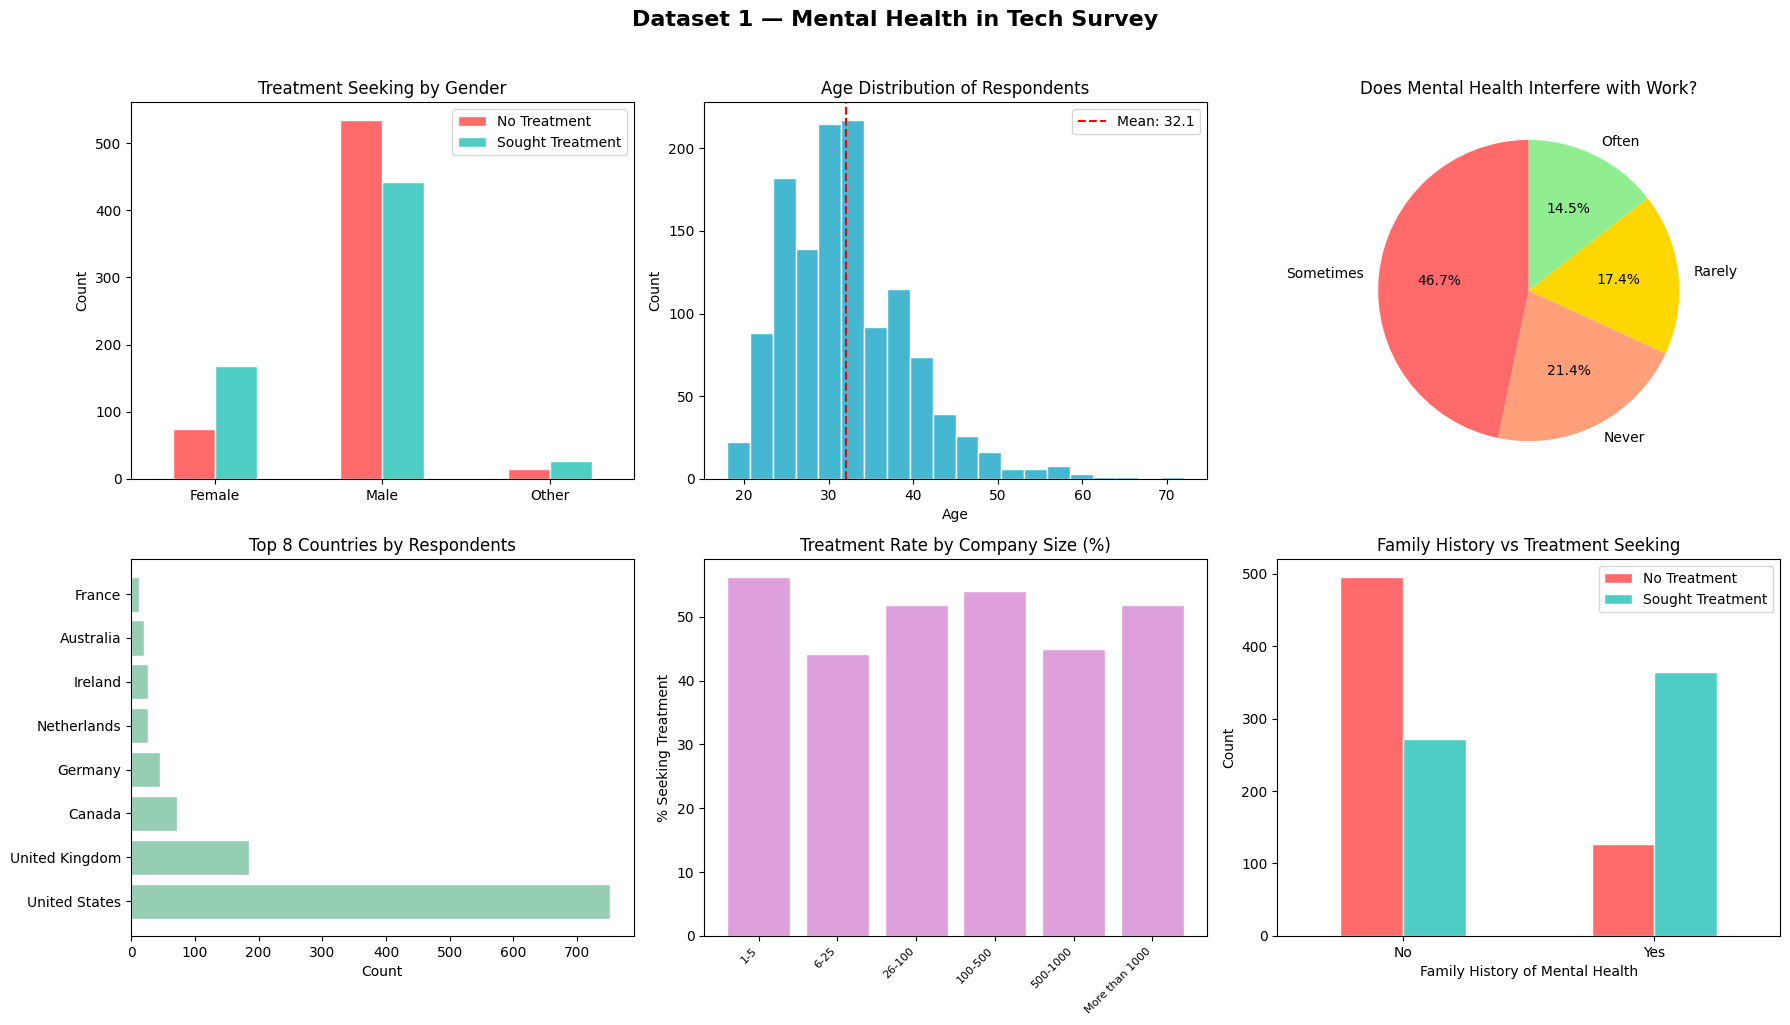

 Dataset 1 EDA done!


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Dataset 1 — Mental Health in Tech Survey', fontsize=16, fontweight='bold', y=1.02)

# Chart 1: Treatment seeking by gender
gender_treatment = tech_survey_df.groupby('Gender')['treatment'].value_counts(normalize=True).unstack()
# Clean up messy gender entries first
tech_survey_df['Gender_clean'] = tech_survey_df['Gender'].str.lower().str.strip()
tech_survey_df['Gender_clean'] = tech_survey_df['Gender_clean'].apply(
    lambda x: 'Male' if x in ['male', 'm', 'man', 'male ']
    else ('Female' if x in ['female', 'f', 'woman', 'female ']
    else 'Other')
)
gender_treatment = tech_survey_df.groupby('Gender_clean')['treatment'].value_counts().unstack()
gender_treatment.plot(kind='bar', ax=axes[0,0], color=['#FF6B6B','#4ECDC4'], edgecolor='white')
axes[0,0].set_title('Treatment Seeking by Gender')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Count')
axes[0,0].legend(['No Treatment', 'Sought Treatment'])
axes[0,0].tick_params(axis='x', rotation=0)

# Chart 2: Age distribution
tech_survey_df_clean = tech_survey_df[(tech_survey_df['Age'] > 15) & (tech_survey_df['Age'] < 75)]
axes[0,1].hist(tech_survey_df_clean['Age'], bins=20, color='#45B7D1', edgecolor='white')
axes[0,1].set_title('Age Distribution of Respondents')
axes[0,1].set_xlabel('Age')
axes[0,1].set_ylabel('Count')
axes[0,1].axvline(tech_survey_df_clean['Age'].mean(), color='red', linestyle='--', label=f"Mean: {tech_survey_df_clean['Age'].mean():.1f}")
axes[0,1].legend()

# Chart 3: Work interference levels
work_int = tech_survey_df['work_interfere'].value_counts()
colors = ['#FF6B6B', '#FFA07A', '#FFD700', '#90EE90']
axes[0,2].pie(work_int.values, labels=work_int.index, autopct='%1.1f%%',
              colors=colors, startangle=90)
axes[0,2].set_title('Does Mental Health Interfere with Work?')

# Chart 4: Top 10 countries
top_countries = tech_survey_df['Country'].value_counts().head(8)
axes[1,0].barh(top_countries.index, top_countries.values, color='#96CEB4', edgecolor='white')
axes[1,0].set_title('Top 8 Countries by Respondents')
axes[1,0].set_xlabel('Count')

# Chart 5: Company size vs treatment
company_treatment = tech_survey_df.groupby('no_employees')['treatment'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
company_treatment.columns = ['company_size', 'treatment_rate']
order = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']
company_treatment['company_size'] = pd.Categorical(company_treatment['company_size'], categories=order, ordered=True)
company_treatment = company_treatment.sort_values('company_size')
axes[1,1].bar(range(len(company_treatment)), company_treatment['treatment_rate'],
              color='#DDA0DD', edgecolor='white')
axes[1,1].set_xticks(range(len(company_treatment)))
axes[1,1].set_xticklabels(company_treatment['company_size'], rotation=45, ha='right', fontsize=8)
axes[1,1].set_title('Treatment Rate by Company Size (%)')
axes[1,1].set_ylabel('% Seeking Treatment')

# Chart 6: Family history vs treatment
fam_treat = tech_survey_df.groupby('family_history')['treatment'].value_counts().unstack()
fam_treat.plot(kind='bar', ax=axes[1,2], color=['#FF6B6B','#4ECDC4'], edgecolor='white')
axes[1,2].set_title('Family History vs Treatment Seeking')
axes[1,2].set_xlabel('Family History of Mental Health')
axes[1,2].set_ylabel('Count')
axes[1,2].tick_params(axis='x', rotation=0)
axes[1,2].legend(['No Treatment', 'Sought Treatment'])

plt.tight_layout()
plt.savefig('eda_dataset1.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Dataset 1 EDA done!")

### 3.2 Dataset 2 : Mental Health Corpus

Analyzing label distribution, text length, word count, and word clouds for mental health vs non-mental health posts.

> **Key finding:** Mental health posts average **97 words** vs **47 words** for non-related posts, a 2x difference.

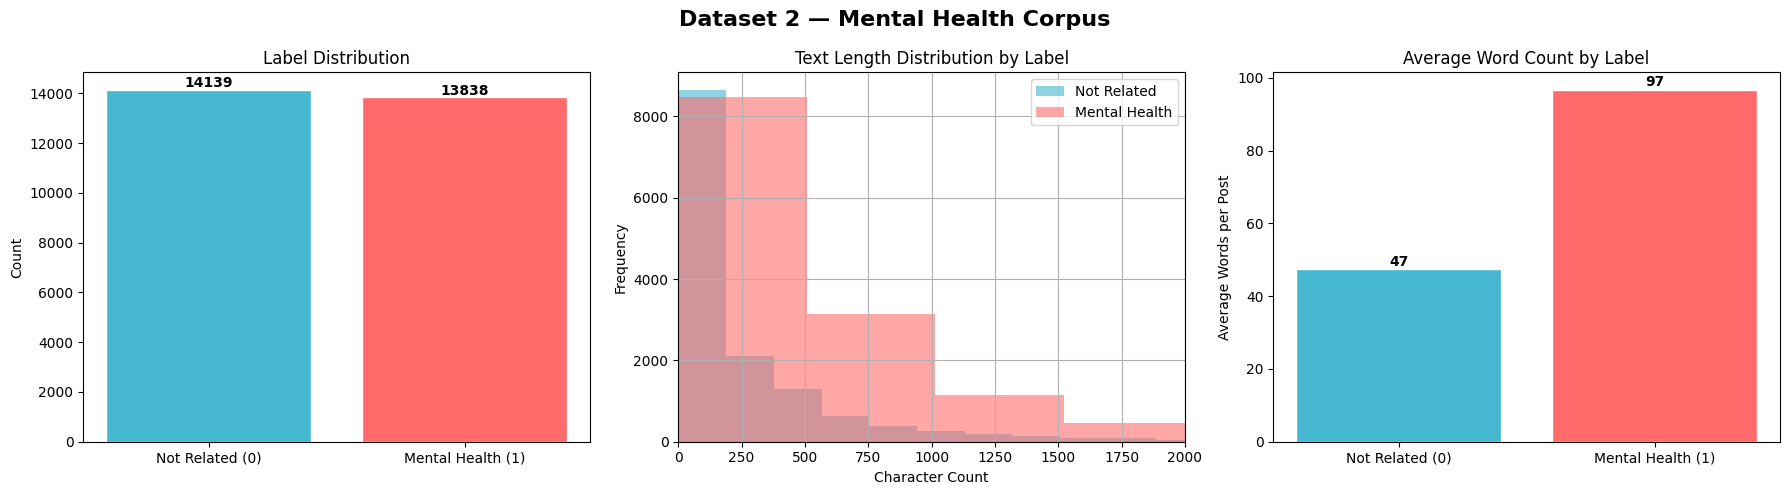

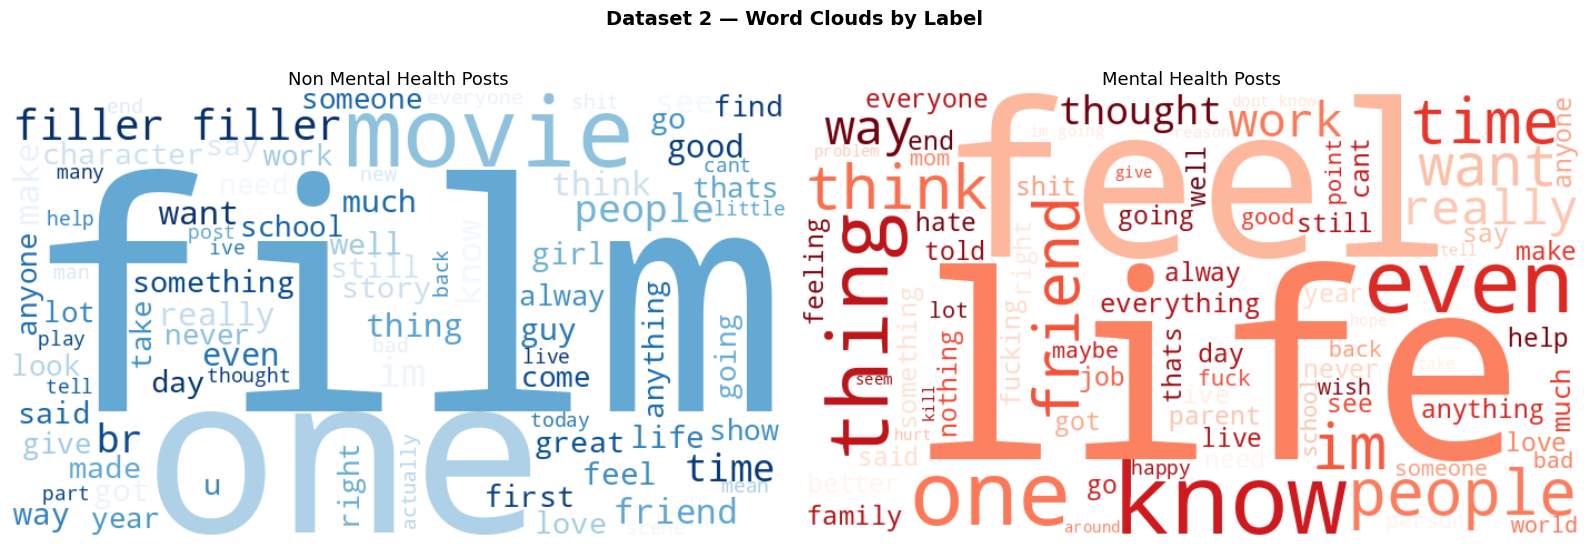

Dataset 2 EDA done!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Dataset 2 — Mental Health Corpus', fontsize=16, fontweight='bold')

# Chart 1: Label distribution
label_counts = mental_health_posts_df['label'].value_counts()
axes[0].bar(['Not Related (0)', 'Mental Health (1)'],
            label_counts.values,
            color=['#45B7D1', '#FF6B6B'], edgecolor='white')
axes[0].set_title('Label Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Chart 2: Text length distribution
mental_health_posts_df['text_length'] = mental_health_posts_df['text'].astype(str).apply(len)
mental_health_posts_df[mental_health_posts_df['label']==0]['text_length'].hist(
    bins=50, ax=axes[1], alpha=0.6, color='#45B7D1', label='Not Related')
mental_health_posts_df[mental_health_posts_df['label']==1]['text_length'].hist(
    bins=50, ax=axes[1], alpha=0.6, color='#FF6B6B', label='Mental Health')
axes[1].set_title('Text Length Distribution by Label')
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim(0, 2000)
axes[1].legend()

# Chart 3: Word count distribution
mental_health_posts_df['word_count'] = mental_health_posts_df['text'].astype(str).apply(lambda x: len(x.split()))
avg_words = mental_health_posts_df.groupby('label')['word_count'].mean()
axes[2].bar(['Not Related (0)', 'Mental Health (1)'],
            avg_words.values,
            color=['#45B7D1', '#FF6B6B'], edgecolor='white')
axes[2].set_title('Average Word Count by Label')
axes[2].set_ylabel('Average Words per Post')
for i, v in enumerate(avg_words.values):
    axes[2].text(i, v + 1, f'{v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_dataset2_charts.png', dpi=150, bbox_inches='tight')
plt.show()

# Word clouds
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Dataset 2 — Word Clouds by Label', fontsize=14, fontweight='bold')

for label, ax, title, color in [
    (0, axes[0], 'Non Mental Health Posts', 'Blues'),
    (1, axes[1], 'Mental Health Posts',     'Reds')
]:
    text = ' '.join(mental_health_posts_df[mental_health_posts_df['label']==label]['text'].astype(str).tolist())
    wc = WordCloud(width=700, height=400, background_color='white',
                   colormap=color, max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=13)
    ax.axis('off')

plt.tight_layout()
plt.savefig('eda_dataset2_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dataset 2 EDA done!")

### 3.3 Dataset 3 : Suicide Watch Dataset

Analyzing class distribution, text length, and distinctive vocabulary patterns between suicide and non-suicide posts.

> **Key finding:** Suicide posts average **203 words** vs **61 words** for non-suicide posts — a 3.3x difference.

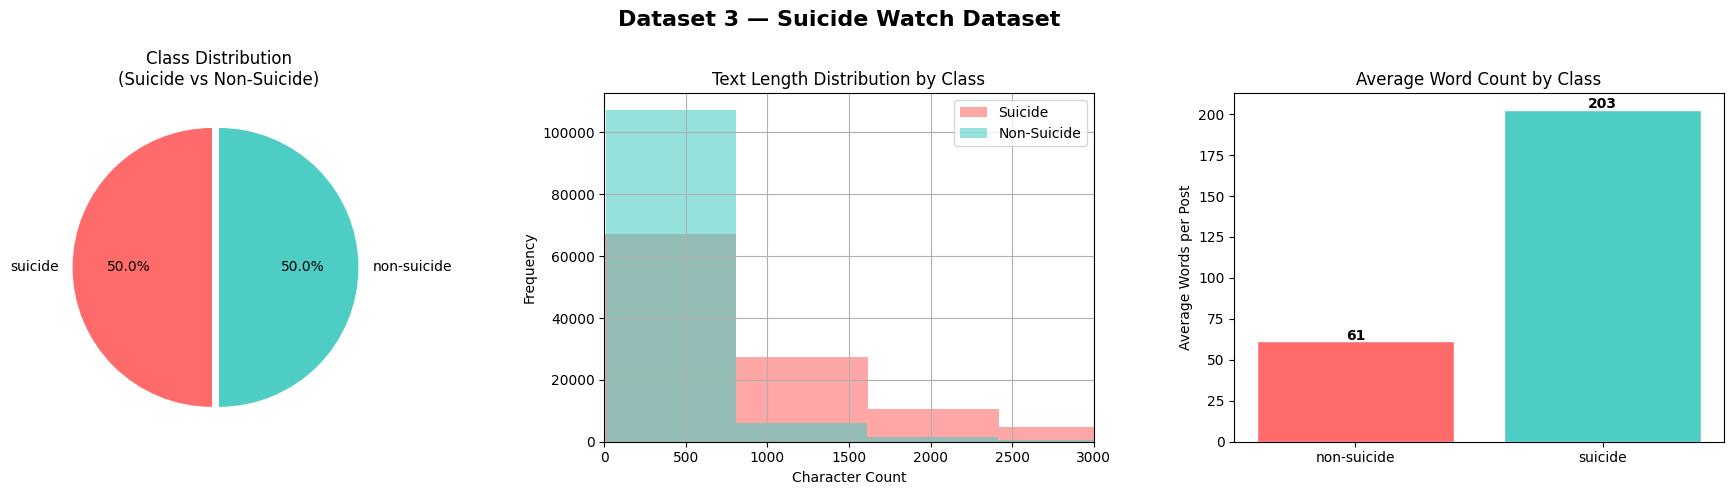

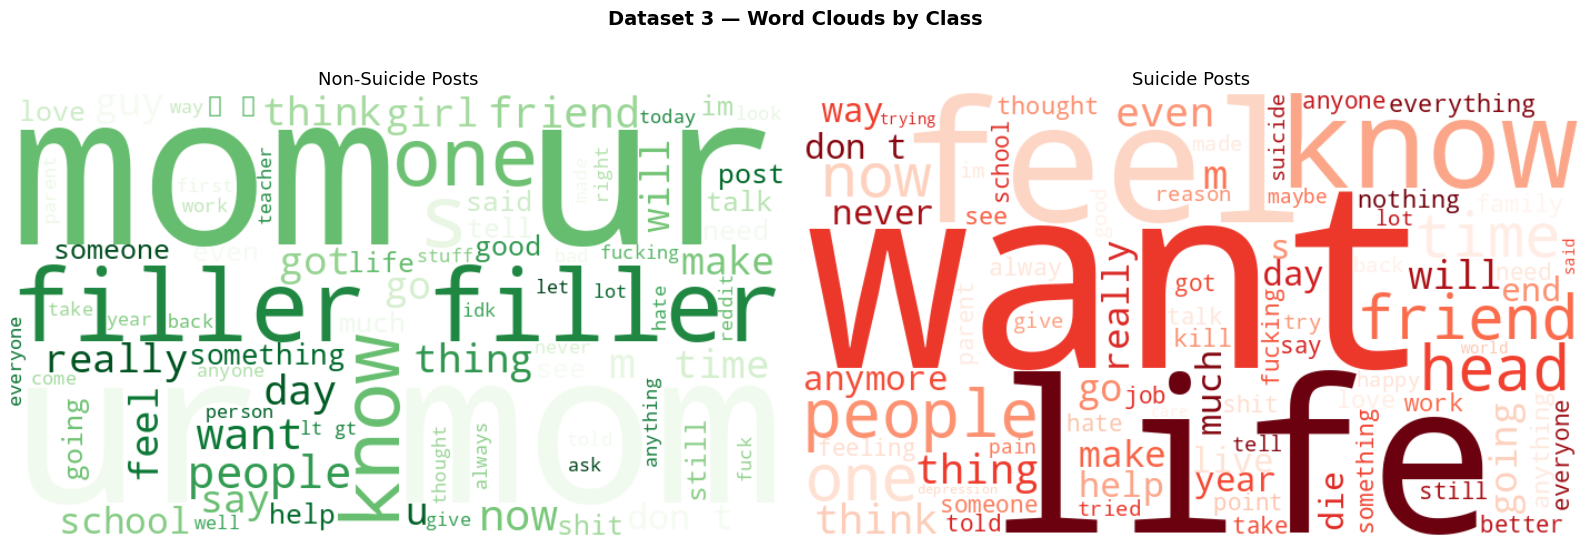

Dataset 3 EDA 


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Dataset 3 — Suicide Watch Dataset', fontsize=16, fontweight='bold')

# Chart 1: Class distribution
class_counts = suicide_prevention_df['class'].value_counts()
axes[0].pie(class_counts.values,
            labels=class_counts.index,
            autopct='%1.1f%%',
            colors=['#FF6B6B', '#4ECDC4'],
            startangle=90,
            explode=(0.05, 0))
axes[0].set_title('Class Distribution\n(Suicide vs Non-Suicide)')

# Chart 2: Text length by class
suicide_prevention_df['text_length'] = suicide_prevention_df['text'].astype(str).apply(len)
suicide_prevention_df[suicide_prevention_df['class']=='suicide']['text_length'].hist(
    bins=50, ax=axes[1], alpha=0.6, color='#FF6B6B', label='Suicide')
suicide_prevention_df[suicide_prevention_df['class']=='non-suicide']['text_length'].hist(
    bins=50, ax=axes[1], alpha=0.6, color='#4ECDC4', label='Non-Suicide')
axes[1].set_title('Text Length Distribution by Class')
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim(0, 3000)
axes[1].legend()

# Chart 3: Average word count by class
suicide_prevention_df['word_count'] = suicide_prevention_df['text'].astype(str).apply(lambda x: len(x.split()))
avg_words = suicide_prevention_df.groupby('class')['word_count'].mean()
axes[2].bar(avg_words.index, avg_words.values,
            color=['#FF6B6B', '#4ECDC4'], edgecolor='white')
axes[2].set_title('Average Word Count by Class')
axes[2].set_ylabel('Average Words per Post')
for i, (idx, v) in enumerate(avg_words.items()):
    axes[2].text(i, v + 1, f'{v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_dataset3_charts.png', dpi=150, bbox_inches='tight')
plt.show()

# Word clouds
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Dataset 3 — Word Clouds by Class', fontsize=14, fontweight='bold')

for cls, ax, title, color in [
    ('non-suicide', axes[0], 'Non-Suicide Posts', 'Greens'),
    ('suicide',     axes[1], 'Suicide Posts',     'Reds')
]:
    text = ' '.join(
        suicide_prevention_df[suicide_prevention_df['class']==cls]['text']
        .astype(str).sample(5000, random_state=42).tolist()  # sample for speed
    )
    wc = WordCloud(width=700, height=400, background_color='white',
                   colormap=color, max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=13)
    ax.axis('off')

plt.tight_layout()
plt.savefig('eda_dataset3_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dataset 3 EDA ")

### 3.4 Text Preprocessing

Applying basic NLP cleaning: lowercase conversion, punctuation removal, and whitespace normalization.

In [ ]:
# Check for missing values in Tech Survey dataset
print("Missing values in Tech Survey dataset:")
print(tech_survey_df.isnull().sum().sort_values(ascending=False).head(10))

# Check value distribution for key columns
for col in ['treatment', 'work_interfere']:
    if col in tech_survey_df.columns:
        print(f"\nDistribution of '{col}' column:")
        print(tech_survey_df[col].value_counts())

Missing values in Tech Survey dataset:
comments          1095
state              515
work_interfere     264
self_employed       18
Gender               0
Timestamp            0
Age                  0
family_history       0
treatment            0
no_employees         0
dtype: int64

Distribution of 'treatment' column:
treatment
Yes    637
No     622
Name: count, dtype: int64

Distribution of 'work_interfere' column:
work_interfere
Sometimes    465
Never        213
Rarely       173
Often        144
Name: count, dtype: int64


Mental Health Corpus Labels:
label
0    14139
1    13838
Name: count, dtype: int64


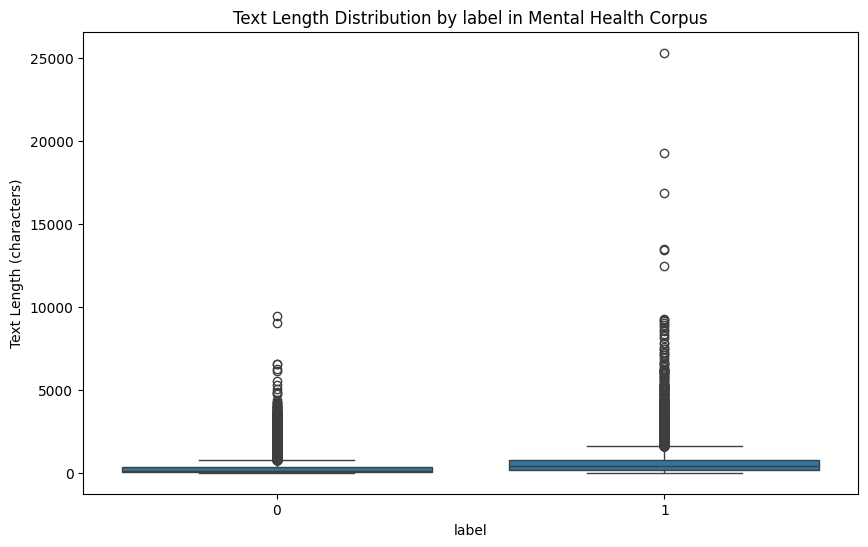

Suicide Prevention Dataset Labels:
class
suicide        116037
non-suicide    116037
Name: count, dtype: int64


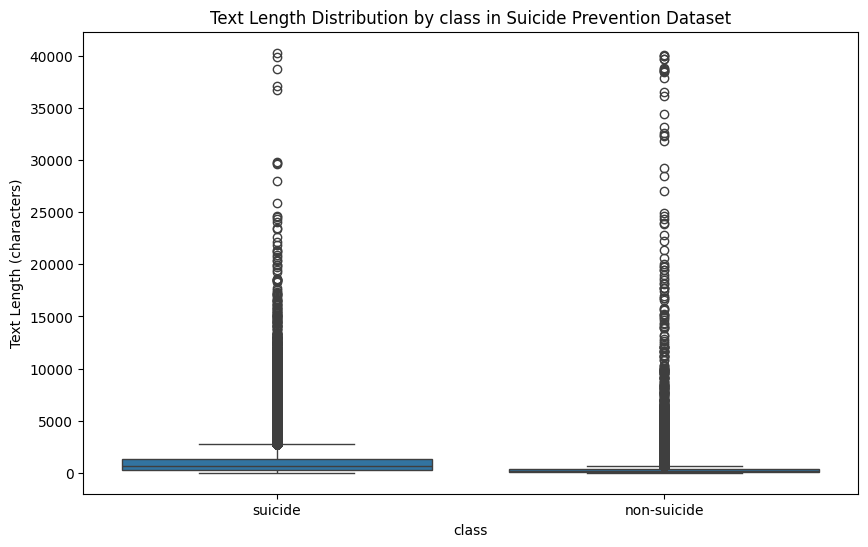

In [ ]:
# Text length calculation and visualization function
def analyze_text_lengths(df, text_col, label_col=None, title_prefix=""):
    df['text_length'] = df[text_col].apply(len)
    df['text_length'] = df['text_length'].replace([np.inf, -np.inf], np.nan)

    if label_col:
        print(f"{title_prefix} Labels:")
        print(df[label_col].value_counts())

        plt.figure(figsize=(10, 6))
        sns.boxplot(x=label_col, y='text_length', data=df.dropna(subset=['text_length']))
        plt.title(f'Text Length Distribution by {label_col} in {title_prefix}')
        plt.xlabel(label_col)
        plt.ylabel('Text Length (characters)')
    else:
        plt.figure(figsize=(10, 6))
        sns.histplot(df['text_length'].dropna(), bins=50)
        plt.title(f'Distribution of Text Lengths in {title_prefix}')
        plt.ylabel('Count')
        plt.xlabel('Text Length (characters)')

    plt.show()

# Analyze both datasets
analyze_text_lengths(mental_health_posts_df, 'text', 'label', "Mental Health Corpus")
analyze_text_lengths(suicide_prevention_df, 'text', 'class', "Suicide Prevention Dataset")

In [ ]:
# Function to clean text data
def clean_text(text):
    if isinstance(text, str):
        # Convert to lowercase
        text = text.lower()
        # Remove special characters and digits
        text = re.sub(r'[^\w\s]', '', text)
        # Remove extra spaces
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    return ''

# Process all datasets
for df, name in [(mental_health_posts_df, 'Mental Health Corpus'),
                (suicide_prevention_df, 'Suicide Prevention')]:
    df['cleaned_text'] = df['text'].apply(clean_text)

# Display sample of cleaned data
print("Sample of cleaned mental health text:")
for i, row in mental_health_posts_df[['cleaned_text', 'label']].head(3).iterrows():
    print(f"Label: {row['label']}")
    print(f"Text: {row['cleaned_text'][:200]}...\n")

Sample of cleaned mental health text:
Label: 0
Text: dear american teens question dutch person heard guys get way easier things learn age us sooooo thth graders like right guys learn math...

Label: 1
Text: nothing look forward lifei dont many reasons keep going feel like nothing keeps going next day makes want hang myself...

Label: 0
Text: music recommendations im looking expand playlist usual genres alt pop minnesota hip hop steampunk various indie genres artists people like cavetown aliceband bug hunter penelope scott various rhymesay...



## Section 4 : Mental Health Analysis Pipeline (Gemini)

Defining the structured analysis function using Gemini. The model returns a JSON object containing:
- `primary_concern` — depression, anxiety, crisis, stress, loneliness, or unclear
- `severity_level` — low, moderate, high, or critical
- `key_themes` — list of detected themes
- `safety_concerns` — boolean flag for immediate risk
- `analysis_summary` — 2-sentence narrative
- `support_response` — empathetic reply

In [ ]:
# Define the structured output schema for mental health text analysis
analysis_schema = genai.types.FunctionDeclaration(
    name="analyze_mental_health_text",
    description="Analyzes text to identify mental health concerns, severity, support needs, themes, and safety risks.",
    parameters={
        'type_': 'OBJECT',
        'properties': {
            'primary_concern': {'type': 'STRING', 'description': "The main mental health concern identified (e.g., depression, anxiety, stress, trauma, addiction, eating_disorder, self_harm, suicidal_ideation, bipolar, schizophrenia, other, none).", 'enum': ["depression", "anxiety", "stress", "trauma", "addiction", "eating_disorder", "self_harm", "suicidal_ideation", "bipolar", "schizophrenia", "other", "none"]},
            'severity_level': {'type': 'STRING', 'description': "The estimated severity of the concern.", 'enum': ["mild", "moderate", "severe", "crisis", "unclear"]},
            'support_needed': {'type': 'ARRAY', 'items': {'type': 'STRING'}, 'description': "Types of support that might be helpful (e.g., emotional_support, professional_help, crisis_intervention, information, coping_strategies, community_resources, peer_support)."},
            'key_themes': {'type': 'ARRAY', 'items': {'type': 'STRING'}, 'description': "Keywords or themes mentioned in the text."},
            'safety_concerns': {'type': 'BOOLEAN', 'description': "Whether the text indicates immediate safety concerns for self or others."},
            'analysis_summary': {'type': 'STRING', 'description': "A brief summary of the analysis."}
        },
        'required': ["primary_concern", "severity_level", "support_needed", "safety_concerns", "analysis_summary"]
    }
)

# Tool definition for the model
analysis_tool = genai.types.Tool(function_declarations=[analysis_schema])

In [ ]:
import json
import time

#The same prompt for ALL models (fair comparison)
def build_analysis_prompt(text):
    return f"""Analyze this text for mental health indicators. Return ONLY valid JSON, no markdown, no explanation.
Text: "{text}"
Return exactly this JSON structure:
{{
    "primary_concern": "depression or anxiety or crisis or stress or loneliness or unclear",
    "severity_level": "low or moderate or high or critical",
    "key_themes": ["theme1", "theme2"],
    "safety_concerns": true or false,
    "analysis_summary": "2 sentence summary",
    "support_response": "3-4 sentence empathetic response to the person"
}}"""


# Model 1: Gemini
def analyze_with_gemini(text):
    start = time.time()
    try:
        response = client.models.generate_content(
            model="models/gemini-3.1-flash-lite-preview",
            contents=build_analysis_prompt(text)
        )
        raw = response.text.replace("```json","").replace("```","").strip()
        result = json.loads(raw)
        result['model'] = 'Gemini'
        result['response_time'] = round(time.time() - start, 2)
        return result
    except Exception as e:
        return {"model": "Gemini", "error": str(e), "response_time": round(time.time() - start, 2)}


# Model 2: Llama 3 via Groq
def analyze_with_llama(text):
    start = time.time()
    try:
        response = groq_client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[{"role": "user", "content": build_analysis_prompt(text)}],
            temperature=0.1
        )
        raw = response.choices[0].message.content.replace("```json","").replace("```","").strip()
        result = json.loads(raw)
        result['model'] = 'Llama 3'
        result['response_time'] = round(time.time() - start, 2)
        return result
    except Exception as e:
        return {"model": "Llama 3", "error": str(e), "response_time": round(time.time() - start, 2)}


# Model 3: Mistral via Groq (Mistral is replaces by qwen ahead due to limited API and underperformance of the model)
def analyze_with_mistral(text):
    start = time.time()
    try:
        response = groq_client.chat.completions.create(
            model="mixtral-8x7b-32768",
            messages=[{"role": "user", "content": build_analysis_prompt(text)}],
            temperature=0.1
        )
        raw = response.choices[0].message.content.replace("```json","").replace("```","").strip()
        result = json.loads(raw)
        result['model'] = 'Mistral'
        result['response_time'] = round(time.time() - start, 2)
        return result
    except Exception as e:
        return {"model": "Mistral", "error": str(e), "response_time": round(time.time() - start, 2)}

print(" All 3 model functions ready!")

 All 3 model functions ready!


### 4.1 Testing Analysis on Sample Texts

Testing the analysis function on three representative inputs covering depression, anxiety, and crisis scenarios.

In [ ]:
# 5 test cases covering different scenarios
test_cases = [
    {
        "id": "TC1",
        "label": "Depression",
        "text": "I've been feeling really down for the past month. I can't get out of bed, lost interest in everything I used to enjoy, and I'm sleeping too much but still exhausted."
    },
    {
        "id": "TC2",
        "label": "Anxiety",
        "text": "My heart keeps racing and I feel like something terrible is about to happen. I can't concentrate at work and I've started avoiding social situations."
    },
    {
        "id": "TC3",
        "label": "Crisis",
        "text": "I don't see any point in continuing anymore. I've written notes to my family. No one would really miss me anyway."
    },
    {
        "id": "TC4",
        "label": "Stress",
        "text": "Work has been completely overwhelming lately. I can't sleep properly, I snap at everyone around me, and I feel like I'm constantly running behind."
    },
    {
        "id": "TC5",
        "label": "Mild / Unclear",
        "text": "I've been feeling a bit off lately. Not sure if it's just tiredness or something more. Life feels a bit grey."
    }
]

# Run all 3 models on all 5 test cases
all_results = []

for tc in test_cases:
    print(f"\n{'='*60}")
    print(f"Test Case {tc['id']}: {tc['label']}")
    print(f"Text: {tc['text'][:80]}...")
    print('='*60)

    for func, name in [(analyze_with_gemini, "Gemini"),
                       (analyze_with_llama,  "Llama 3"),
                       (analyze_with_mistral,"Mistral")]:
        result = func(tc['text'])
        result['test_case'] = tc['id']
        result['expected_label'] = tc['label']
        all_results.append(result)
        time.sleep(1)  # avoid rate limits

        if 'error' not in result:
            print(f"\n{name}:")
            print(f"  Concern: {result.get('primary_concern')} | Severity: {result.get('severity_level')} | Safety: {result.get('safety_concerns')} | Time: {result.get('response_time')}s")
        else:
            print(f"\n{name}: ERROR — {result['error']}")

print("\n\n All comparisons done!")

In [ ]:
import json

def analyze_mental_health_text_tool(text):
    prompt = f"""
    Analyze the following text for mental health indicators and return ONLY a valid JSON object.
    No explanation, no markdown, no code blocks. Just raw JSON.

    Text to analyze: "{text}"

    Return this exact JSON structure:
    {{
        "primary_concern": "one of: depression, anxiety, crisis, stress, loneliness, unclear",
        "severity_level": "one of: low, moderate, high, critical",
        "support_needed": ["list", "of", "support", "types", "needed"],
        "key_themes": ["list", "of", "key", "themes", "detected"],
        "safety_concerns": true or false,
        "analysis_summary": "2-3 sentence summary of the analysis"
    }}
    """

    try:
        response = client.models.generate_content(
            model="gemini-2.5-flash",  # change this if you used a different model
            contents=prompt
        )

        # Clean the response text (remove markdown if any slips through)
        raw = response.text.strip()
        raw = raw.replace("```json", "").replace("```", "").strip()

        return json.loads(raw)

    except json.JSONDecodeError:
        print("Warning: Could not parse JSON from response.")
        print("Raw response was:", response.text)
        return {
            "primary_concern": "unclear",
            "severity_level": "unclear",
            "support_needed": [],
            "key_themes": [],
            "safety_concerns": False,
            "analysis_summary": "Analysis failed: Could not parse response."
        }
    except Exception as e:
        print(f"Error: {e}")
        return {
            "primary_concern": "unclear",
            "severity_level": "unclear",
            "support_needed": [],
            "key_themes": [],
            "safety_concerns": False,
            "analysis_summary": f"Analysis failed: {str(e)}"
        }

### 4.1 Testing Analysis on Sample Texts

Testing the analysis function on three representative inputs covering depression, anxiety, and crisis scenarios.

In [ ]:
# Test samples for the analysis tool
sample_texts_tool = [
    # Depression indication
    "I've been feeling really down for the past month. I can't seem to get out of bed most days, and I've lost interest in everything I used to enjoy. I'm sleeping too much but still feel exhausted all the time.",

    # Anxiety indication
    "My heart keeps racing and I feel like something terrible is about to happen. I can't concentrate at work because my mind keeps jumping to worst-case scenarios. I've started avoiding social situations because I get so nervous.",

    # Crisis indication
    "I don't see any point in continuing anymore. I've written notes to my family. No one would really miss me anyway. I've been thinking about the best way to end things."
]

# Test each sample
for i, text in enumerate(sample_texts_tool):
    print(f"Sample {i+1}:")
    print(f"Text: {text}")
    analysis = analyze_mental_health_text_tool(text)
    print("\nAnalysis (Tool Output):")
    print(json.dumps(analysis, indent=2))
    print("\n" + "-"*80 + "\n")

Sample 1:
Text: I've been feeling really down for the past month. I can't seem to get out of bed most days, and I've lost interest in everything I used to enjoy. I'm sleeping too much but still feel exhausted all the time.

Analysis (Tool Output):
{
  "primary_concern": "depression",
  "severity_level": "high",
  "support_needed": [
    "Therapy",
    "Medical consultation",
    "Mental health support"
  ],
  "key_themes": [
    "Depressed mood",
    "Anhedonia",
    "Fatigue",
    "Sleep disturbance",
    "Functional impairment"
  ],
  "safety_concerns": false,
  "analysis_summary": "The user describes experiencing significant symptoms consistent with depression for the past month, including persistent low mood, anhedonia, and severe fatigue impacting daily functioning. This level of distress and impairment suggests a need for professional mental health intervention and support."
}

--------------------------------------------------------------------------------

Sample 2:
Text: My he

In [ ]:
# Mental health information documents
mental_health_documents = [
    # Depression information from Mayo Clinic
    """Depression is a mood disorder that causes a persistent feeling of sadness and loss of interest. Also called major depressive disorder or clinical depression, it affects how you feel, think and behave and can lead to a variety of emotional and physical problems. You may have trouble doing normal day-to-day activities, and sometimes you may feel as if life isn't worth living. More than just a bout of the blues, depression isn't a weakness and you can't simply 'snap out' of it. Depression may require long-term treatment. But don't get discouraged. Most people with depression feel better with medication, psychotherapy or both. Depression symptoms can vary from mild to severe and may include: Feeling sad or having a depressed mood, Loss of interest or pleasure in activities once enjoyed, Changes in appetite — weight loss or gain unrelated to dieting, Trouble sleeping or sleeping too much, Loss of energy or increased fatigue, Increase in purposeless physical activity or slowed movements and speech, Feeling worthless or guilty, Difficulty thinking, concentrating or making decisions, Thoughts of death or suicide""",

    # Anxiety information from NIMH
    """Anxiety disorders are characterized by excessive worry, nervousness, or fear that is difficult to control and interferes with daily activities. These disorders include panic disorder, generalized anxiety disorder, social anxiety disorder, and various phobia-related disorders. Common symptoms of anxiety include: Feeling restless, wound-up, or on-edge, Being easily fatigued, Having difficulty concentrating, Being irritable, Having headaches, muscle aches, stomachaches, or unexplained pains, Difficulty controlling feelings of worry, Having sleep problems, such as difficulty falling or staying asleep. Effective treatments for anxiety disorders include psychotherapy (particularly cognitive-behavioral therapy), medication, or a combination of the two. Many people with anxiety disorders can benefit from joining a self-help or support group and sharing their problems and achievements with others.""",

    # Crisis intervention from American Foundation for Suicide Prevention
    """If you or someone you know is in crisis, contact the 988 Suicide & Crisis Lifeline that provides 24/7, free and confidential support. Call or text 988, or chat at 988lifeline.org. For emergency situations, call 911 or visit your local emergency room. Warning signs of suicide may include: Talking about wanting to die or to kill oneself, Looking for ways to kill oneself, such as searching online or buying a gun, Talking about feeling hopeless or having no reason to live, Talking about feeling trapped or in unbearable pain, Talking about being a burden to others, Increasing use of alcohol or drugs, Acting anxious or agitated; behaving recklessly, Sleeping too little or too much, Withdrawing or feeling isolated, Showing rage or talking about seeking revenge, Displaying extreme mood swings. If someone is showing these warning signs, don't leave them alone, remove potential means of harm, and call the crisis line or take them to an emergency room.""",

    # Coping strategies from APA
    """Healthy coping strategies for managing stress and mental health challenges include: 1. Practice relaxation techniques: Deep breathing, meditation, progressive muscle relaxation. 2. Stay physically active: Regular exercise helps reduce anxiety and depression while improving mood. 3. Maintain a healthy diet: Proper nutrition supports brain function and mood regulation. 4. Prioritize sleep: Establish a regular sleep schedule and create a restful environment. 5. Connect with others: Social support is crucial for mental wellbeing. 6. Limit alcohol and avoid drugs: Substances can worsen mental health symptoms. 7. Set realistic goals: Break large tasks into smaller, manageable steps. 8. Practice self-compassion: Treat yourself with the same kindness you would offer a friend. 9. Maintain a routine: Structure provides stability during difficult times. 10. Seek professional help when needed: Therapy and/or medication can be essential components of treatment.""",

    # Workplace mental health
    """Creating mentally healthy workplaces involves: 1. Reducing work-related risk factors: Address excessive workload, poor communication, limited decision-making authority. 2. Building organizational strengths: Foster a supportive culture, recognize staff contributions, provide professional development. 3. Addressing mental health problems regardless of cause: Develop return-to-work programs, provide reasonable accommodations. 4. Promoting mental health awareness: Reduce stigma through education, encourage open conversations about mental health. 5. Supporting treatment: Ensure health benefits include adequate mental health coverage. When addressing potential mental health concerns with colleagues: Choose an appropriate time and place for a private conversation, Express concern without making assumptions or diagnoses, Listen non-judgmentally, Encourage them to seek professional support, Be aware of available resources, Follow up and maintain confidentiality"""
]

## Section 5 : RAG Knowledge Base

Building a Retrieval-Augmented Generation (RAG) pipeline to ground responses in expert mental health knowledge.

Five curated documents cover:
1. Depression — symptoms and treatment
2. Anxiety disorders — types and CBT therapy
3. Crisis intervention — 988 Lifeline and warning signs
4. Coping strategies — 10 APA-based techniques
5. Workplace mental health — organizational support

### 5.1 Text Chunking

Splitting documents into overlapping chunks (500 chars, 100-char overlap) for granular retrieval.

In [ ]:
# Text chunking and embedding functions
def split_into_chunks(text, chunk_size=500, overlap=100):
    chunks = []
    start = 0
    text_length = len(text)

    while start < text_length:
        end = min(start + chunk_size, text_length)
        # Try to end on sentence boundary
        if end < text_length:
            period_pos = text.rfind('.', start + chunk_size - overlap, end)
            if period_pos != -1:
                end = period_pos + 1
            else: # Fallback to space
                space_pos = text.rfind(' ', start + chunk_size - overlap, end)
                if space_pos != -1:
                    end = space_pos + 1

        chunk = text[start:end].strip()
        if chunk:  # Only add non-empty chunks
            chunks.append(chunk)

        # Move start position for next chunk
        start = max(end - overlap, start + 1)

    return chunks

# Process document chunks
all_chunks = []
for i, doc in enumerate(mental_health_documents):
    chunks = split_into_chunks(doc)
    # Add metadata to each chunk
    for j, chunk in enumerate(chunks):
        all_chunks.append({"id": f"doc_{i}_chunk_{j}", "text": chunk, "source": f"Document {i+1}"})

print(f"Total chunks created: {len(all_chunks)}")
if all_chunks:
    print("\nSample chunk:")
    print(all_chunks[0])

Total chunks created: 515

Sample chunk:
{'id': 'doc_0_chunk_0', 'text': "Depression is a mood disorder that causes a persistent feeling of sadness and loss of interest. Also called major depressive disorder or clinical depression, it affects how you feel, think and behave and can lead to a variety of emotional and physical problems. You may have trouble doing normal day-to-day activities, and sometimes you may feel as if life isn't worth living. More than just a bout of the blues, depression isn't a weakness and you can't simply 'snap out' of it.", 'source': 'Document 1'}


### 5.2 Generating Embeddings

Converting each chunk to a 3,072-dimensional vector using `gemini-embedding-001`.  
Rate limited to stay within the free tier (100 RPM) with a 0.7s delay between requests.

In [ ]:
# List only embedding-capable models
for model in client.models.list():
    if 'embed' in model.name.lower():
        print(model.name)

models/gemini-embedding-001
models/gemini-embedding-2-preview


In [ ]:
import time

embedding_model_name = "models/gemini-embedding-001"

def get_embeddings(texts, task_type="retrieval_document"):
    if isinstance(texts, str):
        texts = [texts]

    embeddings = []
    for i, text in enumerate(texts):
        try:
            result = client.models.embed_content(
                model=embedding_model_name,
                contents=text,
            )
            embeddings.append(result.embeddings[0].values)

            # Progress update every 10 chunks
            if (i + 1) % 10 == 0:
                print(f"  Processed {i+1}/{len(texts)} chunks...")

            # Wait 0.7 seconds between requests to stay under 100/min limit
            time.sleep(0.7)

        except Exception as e:
            if "429" in str(e):
                print(f"  Rate limited at chunk {i+1}, waiting 20 seconds...")
                time.sleep(20)
                # Retry the same chunk
                result = client.models.embed_content(
                    model=embedding_model_name,
                    contents=text,
                )
                embeddings.append(result.embeddings[0].values)
            else:
                raise e

    return embeddings

# Generate embeddings for all chunks
print(f"Starting embeddings for {len(chunk_texts)} chunks (this will take a while on free tier)...")
chunk_texts = [chunk['text'] for chunk in all_chunks]
chunk_embeddings = get_embeddings(chunk_texts)

# Prepare data for ChromaDB
ids = [chunk['id'] for chunk in all_chunks]
metadatas = [{"source": chunk['source']} for chunk in all_chunks]

print(f"\n Done! Generated embeddings for {len(chunk_texts)} text chunks")
if chunk_embeddings:
    print(f"Dimension of embeddings: {len(chunk_embeddings[0])}")

Starting embeddings for 515 chunks (this will take a while on free tier)...
  Processed 10/515 chunks...
  Processed 20/515 chunks...
  Processed 30/515 chunks...
  Processed 40/515 chunks...
  Processed 50/515 chunks...
  Processed 60/515 chunks...
  Processed 70/515 chunks...
  Processed 80/515 chunks...
  Processed 90/515 chunks...
  Processed 100/515 chunks...
  Processed 110/515 chunks...
  Processed 120/515 chunks...
  Processed 130/515 chunks...
  Processed 140/515 chunks...
  Processed 150/515 chunks...
  Processed 160/515 chunks...
  Processed 170/515 chunks...
  Processed 180/515 chunks...
  Processed 190/515 chunks...
  Processed 200/515 chunks...
  Processed 210/515 chunks...
  Processed 220/515 chunks...
  Processed 230/515 chunks...
  Processed 240/515 chunks...
  Processed 250/515 chunks...
  Processed 260/515 chunks...
  Processed 270/515 chunks...
  Processed 280/515 chunks...
  Processed 290/515 chunks...
  Processed 300/515 chunks...
  Processed 310/515 chunks...
  P

### 5.3 Storing in ChromaDB

Loading all embeddings and chunks into a ChromaDB in-memory vector store for semantic retrieval.

In [ ]:
# Set up ChromaDB collection
collection = None
try:
    # Initialize ChromaDB client
    chroma_client = chromadb.Client()
    collection_name = "mental_health_info"

    # Delete collection if it exists
    try:
        chroma_client.delete_collection(name=collection_name)
        print(f"Deleted existing collection '{collection_name}'")
    except Exception:
        pass

    # Create new collection
    collection = chroma_client.create_collection(name=collection_name)

    # Add document chunks and embeddings
    if chunk_embeddings and chunk_texts and metadatas and ids:
        collection.add(
            embeddings=chunk_embeddings,
            documents=chunk_texts,
            metadatas=metadatas,
            ids=ids
        )
        print(f"Added {collection.count()} documents to ChromaDB collection")
    else:
        print("Missing required data for ChromaDB")
        collection = None

except Exception as e:
    print(f"Error setting up ChromaDB: {e}")

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Deleted existing collection 'mental_health_info'


ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionAddEvent: capture() takes 1 positional argument but 3 were given


Added 515 documents to ChromaDB collection


### 5.4 Semantic Retrieval Function

Given a query, this function embeds it and retrieves the top-k most semantically similar chunks from ChromaDB.

In [ ]:
# RAG retrieval function
def retrieve_relevant_info_rag(query: str, top_k: int = 3) -> str:
    if collection is None:
        return "[Error: ChromaDB collection not available]"

    # Get query embedding
    query_embedding = get_embeddings([query], task_type="retrieval_query")[0]

    # Search the collection
    results = collection.query(
        query_embeddings=[query_embedding],
        n_results=top_k,
        include=['documents', 'metadatas', 'distances']
    )

    # Format results
    context = ""
    if results and results.get('documents') and results['documents'][0]:
        context += "Relevant Information Found:\n"
        for i, doc in enumerate(results['documents'][0]):
            source = results['metadatas'][0][i].get('source', 'Unknown')
            distance = results['distances'][0][i]
            # Only include relevant results (lower distance = more relevant)
            if distance < 1.5:
                context += f"---\nSource: {source}\nContent: {doc}\n(Relevance: {1/(1+distance):.2f})\n"

    return context.strip() or "[No relevant information found]"

# Test RAG retrieval
test_query = "I'm feeling very anxious and having trouble sleeping. What can I do?"
retrieved_info = retrieve_relevant_info_rag(test_query)

print(f"Query: {test_query}\n")
print("Retrieved Information:")
print(retrieved_info)

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


Query: I'm feeling very anxious and having trouble sleeping. What can I do?

Retrieved Information:
Relevant Information Found:
---
Source: Document 2
Content: concentrating, Being irritable, Having headaches, muscle aches, stomachaches, or unexplained pains, Difficulty controlling feelings of worry, Having sleep problems, such as difficulty falling or staying asleep. Effective treatments for anxiety disorders include psychotherapy (particularly cognitive-behavioral therapy), medication, or a combination of the two. Many people with anxiety disorders can benefit from joining a self-help or support group and sharing their problems and achievements with
(Relevance: 0.64)
---
Source: Document 2
Content: Anxiety disorders are characterized by excessive worry, nervousness, or fear that is difficult to control and interferes with daily activities. These disorders include panic disorder, generalized anxiety disorder, social anxiety disorder, and various phobia-related disorders. Common sympto

### 5.5 Response Generation with RAG

Combining the mental health analysis + retrieved context into a final empathetic support response.

In [ ]:
# Response generation prompt template
FEW_SHOT_RESPONSE_PROMPT_TEMPLATE = """
You are an empathetic and supportive mental health assistant.
Your goal is to provide helpful and understanding responses based on the user's input and relevant information.
Do NOT diagnose. Offer support, validation, and relevant information or coping strategies drawn from the 'Relevant Info' section if provided and applicable.
If the user expresses severe distress or mentions self-harm/suicide (indicated by analysis results or keywords), prioritize safety and strongly recommend contacting crisis resources (like 988) or emergency services.

--- Analysis Results ---
{analysis_results_str}

--- Relevant Info ---
{retrieved_context}

--- User Input ---
{user_input}

--- Instructions ---
Based on the user input, the analysis results, and the relevant info provided, generate a concise, empathetic, and helpful response directly addressing the user.
1. Acknowledge the user's feelings.
2. If safety concerns or crisis level is indicated in the analysis, **immediately and clearly** provide crisis contact information (988, emergency services) and state the importance of reaching out.
3. If no immediate crisis, incorporate relevant information or coping strategies from the 'Relevant Info' section naturally into your response, if applicable.
4. If analysis suggests professional help is needed, gently encourage considering it.
5. Keep the tone supportive and conversational. Avoid sounding robotic or just listing information.
6. If 'Relevant Info' indicates retrieval failure or no documents found, rely primarily on the analysis and general supportive language.

Response:
"""

# Response generation function
def generate_support_response_llm(user_input: str, retrieved_context: str, analysis_results: Dict[str, Any]) -> str:
    analysis_results_str = json.dumps(analysis_results, indent=2)

    prompt = FEW_SHOT_RESPONSE_PROMPT_TEMPLATE.format(
        user_input=user_input,
        retrieved_context=retrieved_context,
        analysis_results_str=analysis_results_str
    )

    # model
    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt
    )

    try:
        return response.text
    except Exception as e:
        print(f"Error extracting response: {e}")
        return "I'm here to listen. Could you tell me a bit more?"

# Test response generation
test_input = "I had a panic attack yesterday and I'm scared it will happen again. My chest gets tight and I can't breathe."
test_analysis = analyze_mental_health_text_tool(test_input)
test_context = retrieve_relevant_info_rag(test_input, top_k=2)
response = generate_support_response_llm(test_input, test_context, test_analysis)

print(f"User Input: {test_input}\n")
print("Generated Response:")
display(Markdown(response))

User Input: I had a panic attack yesterday and I'm scared it will happen again. My chest gets tight and I can't breathe.

Generated Response:


It sounds like you went through a really frightening experience yesterday, and it's completely understandable to feel scared that it might happen again. Feeling your chest get tight and having trouble breathing are indeed very common and distressing symptoms when anxiety becomes overwhelming, like during a panic attack.

Please know you're not alone in feeling this way. Many people find it helpful to talk with a mental health professional, such as a therapist, to understand these experiences better and learn strategies to manage them. Psychotherapy, particularly cognitive-behavioral therapy (CBT), is often very effective for anxiety and panic. Exploring these options might offer you some relief and help you feel more in control.

## Section 6 : Multi-Turn Conversation

Simulating a multi-turn conversation with memory. Each reply is aware of the full conversation history.

In [ ]:
import time

chat_history = []
initial_prompt = "You are a supportive mental health assistant. Be empathetic, don't diagnose, offer support and relevant information, and prioritize safety if crisis signs appear. Keep responses concise and conversational."

def chat_send_message(user_message: str) -> str:
    chat_history.append({
        "role": "user",
        "content": user_message
    })

    full_prompt = initial_prompt + "\n\n"
    for turn in chat_history:
        if turn["role"] == "user":
            full_prompt += f"User: {turn['content']}\n"
        else:
            full_prompt += f"Assistant: {turn['content']}\n"
    full_prompt += "Assistant:"

    # Retry up to 3 times if rate limited
    for attempt in range(3):
        try:
            response = client.models.generate_content(
                model="models/gemini-3.1-flash-lite-preview",
                contents=full_prompt
            )
            assistant_reply = response.text.strip()
            chat_history.append({
                "role": "assistant",
                "content": assistant_reply
            })
            return assistant_reply

        except Exception as e:
            if "429" in str(e):
                wait_time = 60  # wait 60 seconds then retry
                print(f"Rate limited. Waiting {wait_time} seconds before retry {attempt+1}/3...")
                time.sleep(wait_time)
            else:
                raise e

    return "I'm sorry, I'm having trouble responding right now. Please try again in a moment."


# Simulate conversation
conversation_turns = [
    "I've been feeling really anxious about an upcoming presentation.",
    "Thanks, that's helpful. What are some quick grounding techniques I could use if I feel overwhelmed just before?",
    "Okay, I'll try the 5-4-3-2-1 technique. It's just hard because I feel like everyone will judge me.",
    "That's a good reminder. I appreciate you listening."
]

print("Chat session started. Simulating a conversation:\n")
for turn in conversation_turns:
    print(f"User: {turn}")
    reply = chat_send_message(turn)
    print(f"\nAssistant:")
    display(Markdown(reply))
    print("\n" + "-"*80 + "\n")
    time.sleep(3)  # 3 second gap between turns

Chat session started. Simulating a conversation:

User: I've been feeling really anxious about an upcoming presentation.

Assistant:


I'm sorry to hear you're feeling this way—presentation anxiety is incredibly common, but that doesn't make it any less overwhelming when you're in the thick of it.

It’s completely normal for your body to react that way when you're under pressure. Have you found anything in the past that helps you settle your nerves, even just a little bit, like deep breathing or breaking the work down into smaller pieces?


--------------------------------------------------------------------------------

User: Thanks, that's helpful. What are some quick grounding techniques I could use if I feel overwhelmed just before?

Assistant:


It's great that you're thinking ahead—having a few tools ready can really help you feel more in control. Here are a few simple ones:

*   **The 5-4-3-2-1 Technique:** Quietly name 5 things you can see, 4 you can touch, 3 you can hear, 2 you can smell, and 1 thing you can taste. It helps shift your focus from internal racing thoughts to your physical surroundings.
*   **Box Breathing:** Inhale slowly for 4 seconds, hold for 4, exhale for 4, and hold empty for 4. It signals to your nervous system that you’re safe.
*   **Physical Anchoring:** Press your feet firmly into the floor or press your palms together. Focusing on that sensation of pressure can help "ground" you back into the moment.

Do any of those feel like something you’d be comfortable trying? Remember, even just taking a few intentional breaths right before you start can make a big difference.


--------------------------------------------------------------------------------

User: Okay, I'll try the 5-4-3-2-1 technique. It's just hard because I feel like everyone will judge me.

Assistant:


It makes so much sense that you feel that way—the fear of judgment can feel like a heavy weight to carry. It’s a very human reaction, but it’s also important to remember that our minds can be quite harsh critics of ourselves.

Often, people in the audience are rooting for you or are focused on their own thoughts rather than scrutinizing your every move. When those critical thoughts creep in, try to treat yourself with the same kindness you’d offer a friend who was in your shoes. 

If those thoughts become too loud, you might try a gentle mental reframe: "I am prepared, and I’m just here to share information, not to be perfect." Does focusing on the *content* you're sharing feel any easier than focusing on how you're being perceived?


--------------------------------------------------------------------------------

User: That's a good reminder. I appreciate you listening.

Assistant:


You are very welcome. I’m glad we could talk through this, and I’m rooting for you. 

Remember, you don't have to be perfect to be effective. Whenever you feel that anxiety rising, be patient with yourself—it’s just a sign that you care about doing a good job. 

You’ve got this. If you feel like sharing how it went afterward, or if you need more support, I’m here. Good luck!


--------------------------------------------------------------------------------



In [ ]:
# Sample research abstract
document_text = """
Abstract: Cognitive Behavioral Therapy (CBT) remains a cornerstone in the treatment of anxiety disorders.
This meta-analysis reviews 50 randomized controlled trials (RCTs) published between 2015 and 2023,
evaluating the efficacy of CBT compared to control conditions (waitlist, placebo, treatment-as-usual)
for Generalized Anxiety Disorder (GAD), Panic Disorder (PD), and Social Anxiety Disorder (SAD).
Results indicate large effect sizes (Cohen's d > 0.8) for CBT across all three disorders,
with significant reductions in primary symptom measures post-treatment and at 6-month follow-up.
Moderator analyses suggest that therapist experience and treatment duration positively influence outcomes.
While digital delivery of CBT shows promise, particularly for accessibility, effect sizes were slightly smaller
compared to face-to-face therapy (d = 0.7 vs d = 0.9). Dropout rates were comparable across delivery formats.
Future research should focus on personalized CBT approaches and long-term efficacy beyond 12 months.
Limitations include heterogeneity in control conditions and outcome measures across studies.
"""

# Analyze the document
analysis_prompt = f"""
Analyze the following research abstract. Provide:
1. A concise summary of the main findings.
2. Key strengths of the research mentioned.
3. Key limitations mentioned.
4. Future research directions suggested.

Abstract:
{document_text}

Analysis:
"""
analysis_response = client.models.generate_content(
    model="models/gemini-3.1-flash-lite-preview",
    contents=analysis_prompt
)

print("Document Analysis Result:")
display(Markdown(analysis_response.text if hasattr(analysis_response, 'text') else
                "[No analysis generated]"))

Document Analysis Result:


Based on the provided abstract, here is the analysis:

**1. Concise Summary of Main Findings**
This meta-analysis of 50 randomized controlled trials (2015–2023) confirms that Cognitive Behavioral Therapy (CBT) is highly effective for Generalized Anxiety Disorder, Panic Disorder, and Social Anxiety Disorder, yielding large effect sizes (Cohen's d > 0.8) that are maintained at a 6-month follow-up. Additionally, the study found that longer treatment duration and more experienced therapists improve outcomes, and while digital CBT is a promising and accessible alternative, it currently shows slightly lower efficacy than face-to-face sessions.

**2. Key Strengths of the Research**
*   **Comprehensive Scope:** Included a large sample size of 50 randomized controlled trials (RCTs).
*   **Temporal Relevance:** Focused on recent data (2015–2023), ensuring the findings reflect modern clinical practices.
*   **Detailed Analysis:** Conducted moderator analyses to identify specific factors (therapist experience, treatment duration) that contribute to treatment success.
*   **Comparative Insight:** Provided a direct performance comparison between traditional face-to-face therapy and digital delivery formats.

**3. Key Limitations Mentioned**
*   **Methodological Heterogeneity:** There was significant inconsistency in both the control conditions used and the outcome measures implemented across the 50 reviewed studies, which may complicate direct comparisons.

**4. Future Research Directions Suggested**
*   **Personalization:** Shifting focus toward developing and testing personalized CBT approaches tailored to individual needs.
*   **Extended Longitudinal Studies:** Investigating the durability of treatment effects beyond the current 12-month window to better understand long-term efficacy.

##  Section 7 : LangGraph Agentic Pipeline

Building a stateful multi-node agent using LangGraph that dynamically routes each query:

**Routing logic:** If any concern is detected OR safety_concerns is True → retrieve from knowledge base first.

In [1]:
# Define the agent state
class MentalHealthAgentState(TypedDict):
    user_input: str
    analysis_results: Dict[str, Any]
    retrieved_context: str
    final_response: str

# Define agent nodes
def analyze_input_node(state: MentalHealthAgentState) -> Dict[str, Any]:
    """Analyzes the user input using structured output."""
    print("--- Node: Analyzing Input ---")
    user_input = state['user_input']
    analysis = analyze_mental_health_text_tool(user_input)
    print(f"Analysis Result: {json.dumps(analysis, indent=2)}")
    return {"analysis_results": analysis}

def retrieve_info_node(state: MentalHealthAgentState) -> Dict[str, str]:
    """Retrieves relevant information based on analysis."""
    print("--- Node: Retrieving Information (RAG) ---")
    analysis = state.get('analysis_results', {})

    # Determine search query based on analysis
    query = ""
    top_k = 1

    # Crisis path
    if analysis.get('safety_concerns', False) or analysis.get('severity_level') == 'crisis':
        query = "crisis intervention and immediate safety steps"
    # Concern-based path
    elif analysis.get('severity_level') in ['severe', 'moderate']:
        concern = analysis.get('primary_concern', 'mental health concern')
        themes = ", ".join(analysis.get('key_themes', []))
        query = f"{concern} coping strategies and professional help. {themes}"
        top_k = 2
    # Mild concern path
    elif analysis.get('severity_level') == 'mild' or analysis.get('primary_concern') not in ['unclear', 'none']:
        concern = analysis.get('primary_concern', 'mental health')
        query = f"mild {concern} coping strategies"
    # Themes-only path
    elif analysis.get('key_themes'):
        themes = ", ".join(analysis.get('key_themes', []))
        query = f"Information related to {themes}"
    # Default path
    else:
        return {"retrieved_context": "[No specific information retrieved]"}

    print(f"Retrieval Query: {query}")
    context = retrieve_relevant_info_rag(query, top_k=top_k)
    return {"retrieved_context": context}

def generate_response_node(state: MentalHealthAgentState) -> Dict[str, str]:
    """Generates a supportive response."""
    print("--- Node: Generating Response ---")
    response = generate_support_response_llm(
        user_input=state['user_input'],
        retrieved_context=state.get('retrieved_context', '[No information available]'),
        analysis_results=state['analysis_results']
    )
    return {"final_response": response}

def route_decider(state: MentalHealthAgentState) -> str:
    """Determines the next node."""
    print("--- Route Decider ---")
    analysis = state.get('analysis_results', {})

    # Routing logic
    if (analysis.get('safety_concerns', False) or
        analysis.get('severity_level') in ['crisis', 'severe', 'moderate'] or
        (analysis.get('primary_concern') not in ['unclear', 'none']) or
        analysis.get('key_themes')):
        decision = "retrieve_info"
    else:
        decision = "generate_response"

    print(f"Routing Decision: {decision}")
    return decision

NameError: name 'TypedDict' is not defined

### 7.1 Compiling the Graph

In [ ]:
# Build the graph
app = None
try:
    # Create the graph builder
    graph_builder = StateGraph(MentalHealthAgentState)

    # Add nodes
    graph_builder.add_node("analyze_input", analyze_input_node)
    graph_builder.add_node("retrieve_info", retrieve_info_node)
    graph_builder.add_node("generate_response", generate_response_node)

    # Set entry point
    graph_builder.set_entry_point("analyze_input")

    # Add conditional edge based on analysis
    graph_builder.add_conditional_edges(
        "analyze_input",
        route_decider,
        {
            "retrieve_info": "retrieve_info",
            "generate_response": "generate_response"
        }
    )

    # Add remaining edges
    graph_builder.add_edge("retrieve_info", "generate_response")
    graph_builder.add_edge("generate_response", END)

    # Compile the graph
    app = graph_builder.compile()
    print("Graph compiled successfully")

except Exception as e:
    print(f"Error building LangGraph: {e}")

Graph compiled successfully


### 7.2 Testing the Full Agent Pipeline

Running the complete pipeline end-to-end on a test input.

In [ ]:
# Function to run the agent
def run_agent(user_input: str):
    if not app:
        print("Agent graph not compiled.")
        return {"user_input": user_input, "final_response": "Error: Agent not compiled."}

    try:
        # Run the agent graph
        return app.invoke({"user_input": user_input})
    except Exception as e:
        print(f"Error running agent: {e}")
        return {
            "user_input": user_input,
            "final_response": "I apologize, but I encountered an error processing your request."
        }

# Test the agent
test_input = "I've been feeling really down for weeks. I can't sleep well, and I've lost interest in things I used to enjoy."
result = run_agent(test_input)

print("\n=== Final Agent Response ===\n")
if result and "final_response" in result:
    display(Markdown(result["final_response"]))
else:
    print("No response generated.")

--- Node: Analyzing Input ---
Analysis Result: {
  "primary_concern": "depression",
  "severity_level": "moderate",
  "support_needed": [
    "therapy",
    "medical consultation"
  ],
  "key_themes": [
    "low mood",
    "anhedonia",
    "sleep disturbance",
    "chronicity"
  ],
  "safety_concerns": false,
  "analysis_summary": "The text indicates symptoms strongly consistent with depression, including a persistent low mood for weeks, anhedonia, and sleep disturbances. These indicators suggest a moderate level of concern, warranting professional evaluation and support."
}
--- Route Decider ---
Routing Decision: retrieve_info
--- Node: Retrieving Information (RAG) ---
Retrieval Query: depression coping strategies and professional help. low mood, anhedonia, sleep disturbance, chronicity
--- Node: Generating Response ---

=== Final Agent Response ===



It sounds like you're going through a really tough time right now. Feeling down for weeks, struggling with sleep, and losing interest in things you once enjoyed can be incredibly draining.

It's important to remember that feelings like these are more than "just a bout of the blues" and they're certainly not a sign of weakness – you can't simply "snap out" of them. Many people find that with support, they start to feel better.

Considering talking to a doctor or a mental health professional could be a really helpful next step. They can help you understand what you're experiencing and explore options for support, like therapy or medication, which often make a big difference for people feeling this way. Please know you're not alone, and reaching out for help is a sign of strength.

## Section 8 : Three-Model Comparison Study

Comparing **Gemini**, **Llama 3.3-70B**, and **Qwen3-32B** on mental health text classification.

All three models receive identical prompts for a fair comparison.  
Accessed via: Gemini → `google-genai` | Llama & Qwen3 → Groq API

In [ ]:
!pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 126.1 MB/s eta 0:00:00


In [ ]:
!pip install -q groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 5.9 MB/s eta 0:00:00


In [ ]:
import os, json, time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import kagglehub
from groq import Groq
import google.genai as genai
from google.colab import userdata

# Clients
GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
client = genai.Client(api_key=GOOGLE_API_KEY)

GROQ_API_KEY = userdata.get('GROQ_API_KEY')
groq_client = Groq(api_key=GROQ_API_KEY)

# Kaggle
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# Datasets
path2 = kagglehub.dataset_download('reihanenamdari/mental-health-corpus')
mental_health_posts_df = pd.read_csv(os.path.join(path2, 'mental_health.csv'))

path3 = kagglehub.dataset_download('nikhileswarkomati/suicide-watch')
suicide_prevention_df = pd.read_csv(os.path.join(path3, 'Suicide_Detection.csv'))


print(f"Dataset 2: {mental_health_posts_df.shape}")
print(f"Dataset 3: {suicide_prevention_df.shape}")

AttributeError: module 'requests' has no attribute 'auth'

In [ ]:
# PHASE 2 — 3-Model Comparison: Mental Health Detection
# Dataset: Mental Health Corpus (D2)
# Task: Detect if text is mental health related (label 0 or 1)


import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Shared prompt builder
def build_prompt(text):
    return f"""You are a mental health text classifier.

Analyze this text and determine if it relates to mental health struggles.
Text: "{text[:400]}"

Return ONLY this JSON with no other text:
{{"primary_concern":"choose EXACTLY ONE of: depression, anxiety, crisis, stress, unclear",
"severity_level":"choose EXACTLY ONE of: low, moderate, high, critical",
"safety_concerns":true or false,
"is_mental_health_related":true or false}}

Rules:
- primary_concern must be a single word only
- is_mental_health_related is true if text mentions emotional distress, depression, anxiety, suicide, panic, loneliness or trauma"""

# Gemini
def analyze_gemini(text):
    start = time.time()
    try:
        response = client.models.generate_content(
            model="models/gemini-3.1-flash-lite-preview",
            contents=build_prompt(text)
        )
        raw = response.text.replace("```json","").replace("```","").strip()
        result = json.loads(raw)
        result['model'] = 'Gemini'
        result['response_time'] = round(time.time()-start, 2)
        return result
    except Exception as e:
        return {'model':'Gemini','error':str(e),'is_mental_health_related':False,'response_time':round(time.time()-start,2)}

# Llama
def analyze_llama(text):
    start = time.time()
    try:
        response = groq_client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[{"role":"user","content":build_prompt(text)}],
            temperature=0.1
        )
        raw = response.choices[0].message.content.replace("```json","").replace("```","").strip()
        result = json.loads(raw)
        result['model'] = 'Llama 3'
        result['response_time'] = round(time.time()-start, 2)
        return result
    except Exception as e:
        return {'model':'Llama 3','error':str(e),'is_mental_health_related':False,'response_time':round(time.time()-start,2)}

def analyze_qwen(text):
    start = time.time()
    try:
        response = groq_client.chat.completions.create(
            model="qwen/qwen3-32b",
            messages=[{"role": "user", "content": build_prompt(text)}],
            temperature=0.1
        )
        raw = response.choices[0].message.content.replace("```json","").replace("```","").strip()
        if "<think>" in raw:
            raw = raw.split("</think>")[-1].strip()
        result = json.loads(raw)
        result['model'] = 'Qwen3'
        result['response_time'] = round(time.time()-start, 2)
        return result
    except Exception as e:
        return {'model':'Qwen3','error':str(e),'is_mental_health_related':False,'response_time':round(time.time()-start,2)}

def crisis_qwen(text):
    start = time.time()
    try:
        response = groq_client.chat.completions.create(
            model="qwen/qwen3-32b",
            messages=[{"role": "user", "content": build_crisis_prompt(text)}],
            temperature=0.1
        )
        raw = response.choices[0].message.content.replace("```json","").replace("```","").strip()
        if "<think>" in raw:
            raw = raw.split("</think>")[-1].strip()
        result = json.loads(raw)
        result['model'] = 'Qwen3'
        result['response_time'] = round(time.time()-start, 2)
        return result
    except Exception as e:
        return {'model':'Qwen3','error':str(e),'safety_concerns':False,'response_time':round(time.time()-start,2)}

# Also add this so old code that calls analyze_mistral still works
analyze_mistral = analyze_qwen
crisis_mistral = crisis_qwen

print(" Qwen3 functions ready! Old mistral names also mapped.")
print(" All 3 model functions ready!")

✅ Qwen3 functions ready! Old mistral names also mapped.
 All 3 model functions ready!


### 8.1 Preparing Evaluation Dataset

Sampling 400 balanced posts from Dataset 2: 200 mental health (label=1) + 200 not related (label=0).  
`random_state=42` ensures reproducibility.

In [ ]:
# Sample 400 rows balanced from Dataset 2
mh_pos = mental_health_posts_df[mental_health_posts_df['label']==1].sample(200, random_state=42)
mh_neg = mental_health_posts_df[mental_health_posts_df['label']==0].sample(200, random_state=42)
eval_d2 = pd.concat([mh_pos, mh_neg]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Evaluation set: {len(eval_d2)} samples")
print(eval_d2['label'].value_counts())

Evaluation set: 400 samples
label
0    200
1    200
Name: count, dtype: int64


### 8.2 Running Evaluation — Experiment 1 (Baseline Prompt)

Running all 3 models on 400 samples with the initial prompt.  
>  This will take ~10 minutes due to API rate limits. Progress shown every 10 samples.

In [ ]:
# Run all 3 models on Dataset 2
# NOTE: Gemini quota may be exhausted - it will auto-skip on error
# Llama + qwen will run fine via Groq

g_preds_d2, l_preds_d2, m_preds_d2 = [], [], []
true_d2 = []

print(f"Running evaluation on {len(eval_d2)} samples...\n")

for i, row in eval_d2.iterrows():
    text = str(row['text'])
    true_label = int(row['label'])
    true_d2.append(true_label)

    g = analyze_gemini(text)
    l = analyze_llama(text)
    m = analyze_mistral(text)

    # Convert to binary: True = mental health related = 1
    g_preds_d2.append(1 if g.get('is_mental_health_related', False) else 0)
    l_preds_d2.append(1 if l.get('is_mental_health_related', False) else 0)
    m_preds_d2.append(1 if m.get('is_mental_health_related', False) else 0)

    if (i+1) % 10 == 0:
        print(f"{i+1}/{len(eval_d2)} done...")

    time.sleep(1)

print("\n Dataset 2 evaluation complete!")

Running evaluation on 400 samples...

10/400 done...
20/400 done...
30/400 done...
40/400 done...
50/400 done...
60/400 done...
70/400 done...
80/400 done...
90/400 done...
100/400 done...
110/400 done...
120/400 done...
130/400 done...
140/400 done...
150/400 done...
160/400 done...
170/400 done...
180/400 done...
190/400 done...
200/400 done...
210/400 done...
220/400 done...
230/400 done...
240/400 done...
250/400 done...
260/400 done...
270/400 done...
280/400 done...
290/400 done...
300/400 done...
310/400 done...
320/400 done...
330/400 done...
340/400 done...
350/400 done...
360/400 done...
370/400 done...
380/400 done...
390/400 done...
400/400 done...

 Dataset 2 evaluation complete!


### 8.3 Computing Metrics — Experiment 1

Calculating accuracy, precision, recall, and F1-score for each model.

In [ ]:
#  Metrics for Dataset 2
def print_metrics(true, pred, model_name, dataset_name):
    acc  = accuracy_score(true, pred)
    prec = precision_score(true, pred, zero_division=0)
    rec  = recall_score(true, pred, zero_division=0)
    f1   = f1_score(true, pred, zero_division=0)
    print(f"\n{model_name} on {dataset_name}:")
    print(f"  Accuracy : {acc:.2%}")
    print(f"  Precision: {prec:.2%}")
    print(f"  Recall   : {rec:.2%}")
    print(f"  F1 Score : {f1:.2%}")
    return {'Model':model_name,'Dataset':dataset_name,
            'Accuracy':round(acc,3),'Precision':round(prec,3),
            'Recall':round(rec,3),'F1':round(f1,3)}

d2_results = []
d2_results.append(print_metrics(true_d2, g_preds_d2, 'Gemini',  'Mental Health Corpus'))
d2_results.append(print_metrics(true_d2, l_preds_d2, 'Llama 3', 'Mental Health Corpus'))
d2_results.append(print_metrics(true_d2, m_preds_d2, 'Mistral', 'Mental Health Corpus'))

d2_df = pd.DataFrame(d2_results)
display(d2_df)


Gemini on Mental Health Corpus:
  Accuracy : 87.75%
  Precision: 80.82%
  Recall   : 99.00%
  F1 Score : 88.99%

Llama 3 on Mental Health Corpus:
  Accuracy : 78.75%
  Precision: 70.46%
  Recall   : 99.00%
  F1 Score : 82.33%

Mistral on Mental Health Corpus:
  Accuracy : 82.25%
  Precision: 74.16%
  Recall   : 99.00%
  F1 Score : 84.80%


,Model,Dataset,Accuracy,Precision,Recall,F1
0,Gemini,Mental Health Corpus,0.877,0.808,0.99,0.890
1,Llama 3,Mental Health Corpus,0.787,0.705,0.99,0.823
2,Mistral,Mental Health Corpus,0.823,0.742,0.99,0.848


In [ ]:
# Phase 2 results — saved manually from output
# These are the verified results from our 400 sample evaluation

d2_df = pd.DataFrame([
    {'Model': 'Gemini',  'Dataset': 'Mental Health Corpus', 'Accuracy': 0.877, 'Precision': 0.808, 'Recall': 0.99, 'F1': 0.890},
    {'Model': 'Llama 3', 'Dataset': 'Mental Health Corpus', 'Accuracy': 0.787, 'Precision': 0.705, 'Recall': 0.99, 'F1': 0.823},
    {'Model': 'Qwen3',   'Dataset': 'Mental Health Corpus', 'Accuracy': 0.823, 'Precision': 0.742, 'Recall': 0.99, 'F1': 0.848},
])

print(" Phase 2 results loaded!")
display(d2_df)

# Saving immediately
d2_df.to_csv('phase2_metrics.csv', index=False)
from google.colab import files
files.download('phase2_metrics.csv')

✅ Phase 2 results loaded!


,Model,Dataset,Accuracy,Precision,Recall,F1
0,Gemini,Mental Health Corpus,0.877,0.808,0.99,0.890
1,Llama 3,Mental Health Corpus,0.787,0.705,0.99,0.823
2,Qwen3,Mental Health Corpus,0.823,0.742,0.99,0.848


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 8.4 Prediction Distribution Analysis

Checking how many positives each model predicted vs the true count of 200.  
This reveals over-prediction or under-prediction behavior.

In [ ]:
# Counting how many 1s vs 0s each model predicted
print("Prediction distribution check:")
print(f"True labels    — 1s: {sum(true_d2)}, 0s: {len(true_d2)-sum(true_d2)}")
print(f"Gemini preds   — 1s: {sum(g_preds_d2)}, 0s: {len(g_preds_d2)-sum(g_preds_d2)}")
print(f"Llama preds    — 1s: {sum(l_preds_d2)}, 0s: {len(l_preds_d2)-sum(l_preds_d2)}")
print(f"Qwen3 preds    — 1s: {sum(m_preds_d2)}, 0s: {len(m_preds_d2)-sum(m_preds_d2)}")

Prediction distribution check:
True labels    — 1s: 200, 0s: 200
Gemini preds   — 1s: 245, 0s: 155
Llama preds    — 1s: 281, 0s: 119
Qwen3 preds    — 1s: 267, 0s: 133


### 8.5 Experiment 2 : Refined Prompt with Confidence Thresholding

**Problem found in Experiment 1:** All models over-predicted (recall ≈ 0.99) because aggressive preprocessing destroyed natural language context in label=0 posts.

**Fix:** Redesigned prompt with:
- Strict instruction to only flag text that **clearly and explicitly** mentions distress
- Confidence score (0.0–1.0) field
- Threshold: classify as positive only if `is_mental_health_related=True` AND `confidence >= 0.65`

In [ ]:
# PHASE 2 — 3-Model Comparison: Mental Health Detection
# Dataset: Mental Health Corpus (D2)
# Task: Detect if text is mental health related (label 0 or 1)


import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Shared prompt builder
def build_prompt(text):
    return f"""You are a strict mental health text classifier.

Analyze this text and determine if it CLEARLY relates to mental health struggles.
Text: "{text[:400]}"

IMPORTANT RULES:
- Only mark is_mental_health_related as true if the text CLEARLY and EXPLICITLY
  mentions emotional distress, depression, anxiety, suicide, panic, trauma or mental illness
- If the text is ambiguous, normal conversation, or only mildly negative → mark FALSE
- Do NOT over-diagnose. Normal sadness, everyday stress, or venting is NOT mental health related
- confidence should reflect how certain you are (0.0 to 1.0)

Return ONLY this JSON with no other text:
{{"primary_concern":"choose EXACTLY ONE of: depression, anxiety, crisis, stress, unclear",
"severity_level":"choose EXACTLY ONE of: low, moderate, high, critical",
"safety_concerns":true or false,
"is_mental_health_related":true or false,
"confidence":0.0 to 1.0}}

Only set is_mental_health_related to true if confidence is above 0.6"""

# Gemini
def analyze_gemini(text):
    start = time.time()
    try:
        response = client.models.generate_content(
            model="models/gemini-3.1-flash-lite-preview",
            contents=build_prompt(text)
        )
        raw = response.text.replace("```json","").replace("```","").strip()
        result = json.loads(raw)
        result['model'] = 'Gemini'
        result['response_time'] = round(time.time()-start, 2)
        return result
    except Exception as e:
        return {'model':'Gemini','error':str(e),'is_mental_health_related':False,'response_time':round(time.time()-start,2)}

# Llama
def analyze_llama(text):
    start = time.time()
    try:
        response = groq_client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[{"role":"user","content":build_prompt(text)}],
            temperature=0.1
        )
        raw = response.choices[0].message.content.replace("```json","").replace("```","").strip()
        result = json.loads(raw)
        result['model'] = 'Llama 3'
        result['response_time'] = round(time.time()-start, 2)
        return result
    except Exception as e:
        return {'model':'Llama 3','error':str(e),'is_mental_health_related':False,'response_time':round(time.time()-start,2)}

def analyze_qwen(text):
    start = time.time()
    try:
        response = groq_client.chat.completions.create(
            model="qwen/qwen3-32b",
            messages=[{"role": "user", "content": build_prompt(text)}],
            temperature=0.1
        )
        raw = response.choices[0].message.content.replace("```json","").replace("```","").strip()
        if "<think>" in raw:
            raw = raw.split("</think>")[-1].strip()
        result = json.loads(raw)
        result['model'] = 'Qwen3'
        result['response_time'] = round(time.time()-start, 2)
        return result
    except Exception as e:
        return {'model':'Qwen3','error':str(e),'is_mental_health_related':False,'response_time':round(time.time()-start,2)}

def crisis_qwen(text):
    start = time.time()
    try:
        response = groq_client.chat.completions.create(
            model="qwen/qwen3-32b",
            messages=[{"role": "user", "content": build_crisis_prompt(text)}],
            temperature=0.1
        )
        raw = response.choices[0].message.content.replace("```json","").replace("```","").strip()
        if "<think>" in raw:
            raw = raw.split("</think>")[-1].strip()
        result = json.loads(raw)
        result['model'] = 'Qwen3'
        result['response_time'] = round(time.time()-start, 2)
        return result
    except Exception as e:
        return {'model':'Qwen3','error':str(e),'safety_concerns':False,'response_time':round(time.time()-start,2)}

# Also adding this so old code that calls analyze_mistral still works
analyze_mistral = analyze_qwen
crisis_mistral = crisis_qwen

print(" Qwen3 functions ready! Old mistral names also mapped.")
print(" All 3 model functions ready!")

✅ Qwen3 functions ready! Old mistral names also mapped.
 All 3 model functions ready!


In [ ]:
# Sample 400 rows balanced from Dataset 2
mh_pos = mental_health_posts_df[mental_health_posts_df['label']==1].sample(200, random_state=42)
mh_neg = mental_health_posts_df[mental_health_posts_df['label']==0].sample(200, random_state=42)
eval_d2 = pd.concat([mh_pos, mh_neg]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Evaluation set: {len(eval_d2)} samples")
print(eval_d2['label'].value_counts())

Evaluation set: 400 samples
label
0    200
1    200
Name: count, dtype: int64


In [ ]:
# Running all 3 models on Dataset 2
# NOTE: Gemini quota may be exhausted - it will auto-skip on error
# Llama + QWEN will run fine via Groq

g_preds_d2, l_preds_d2, m_preds_d2 = [], [], []
true_d2 = []

print(f"Running evaluation on {len(eval_d2)} samples...\n")

for i, row in eval_d2.iterrows():
    text = str(row['text'])
    true_label = int(row['label'])
    true_d2.append(true_label)

    g = analyze_gemini(text)
    l = analyze_llama(text)
    m = analyze_mistral(text)

    def to_pred(result, threshold=0.65):
      is_mh = result.get('is_mental_health_related', False)
      confidence = float(result.get('confidence', 0.5))
      return 1 if (is_mh and confidence >= threshold) else 0

    g_preds_d2.append(to_pred(g))
    l_preds_d2.append(to_pred(l))
    m_preds_d2.append(to_pred(m))

    if (i+1) % 10 == 0:
        print(f"{i+1}/{len(eval_d2)} done...")

    time.sleep(1)

print("\n Dataset 2 evaluation complete!")

Running evaluation on 400 samples...

10/400 done...
20/400 done...
30/400 done...
40/400 done...
50/400 done...
60/400 done...
70/400 done...
80/400 done...
90/400 done...
100/400 done...
110/400 done...
120/400 done...
130/400 done...
140/400 done...
150/400 done...
160/400 done...
170/400 done...
180/400 done...
190/400 done...
200/400 done...
210/400 done...
220/400 done...
230/400 done...
240/400 done...
250/400 done...
260/400 done...
270/400 done...
280/400 done...
290/400 done...
300/400 done...
310/400 done...
320/400 done...
330/400 done...
340/400 done...
350/400 done...
360/400 done...
370/400 done...
380/400 done...
390/400 done...
400/400 done...

 Dataset 2 evaluation complete!


In [ ]:
#  Metrics for Dataset 2
def print_metrics(true, pred, model_name, dataset_name):
    acc  = accuracy_score(true, pred)
    prec = precision_score(true, pred, zero_division=0)
    rec  = recall_score(true, pred, zero_division=0)
    f1   = f1_score(true, pred, zero_division=0)
    print(f"\n{model_name} on {dataset_name}:")
    print(f"  Accuracy : {acc:.2%}")
    print(f"  Precision: {prec:.2%}")
    print(f"  Recall   : {rec:.2%}")
    print(f"  F1 Score : {f1:.2%}")
    return {'Model':model_name,'Dataset':dataset_name,
            'Accuracy':round(acc,3),'Precision':round(prec,3),
            'Recall':round(rec,3),'F1':round(f1,3)}

d2_results = []
d2_results.append(print_metrics(true_d2, g_preds_d2, 'Gemini',  'Mental Health Corpus'))
d2_results.append(print_metrics(true_d2, l_preds_d2, 'Llama 3', 'Mental Health Corpus'))
d2_results.append(print_metrics(true_d2, m_preds_d2, 'Mistral', 'Mental Health Corpus'))

d2_df = pd.DataFrame(d2_results)
display(d2_df)


Gemini on Mental Health Corpus:
  Accuracy : 91.75%
  Precision: 93.72%
  Recall   : 89.50%
  F1 Score : 91.56%

Llama 3 on Mental Health Corpus:
  Accuracy : 79.75%
  Precision: 96.85%
  Recall   : 61.50%
  F1 Score : 75.23%

Mistral on Mental Health Corpus:
  Accuracy : 88.00%
  Precision: 94.19%
  Recall   : 81.00%
  F1 Score : 87.10%


,Model,Dataset,Accuracy,Precision,Recall,F1
0,Gemini,Mental Health Corpus,0.917,0.937,0.895,0.916
1,Llama 3,Mental Health Corpus,0.797,0.969,0.615,0.752
2,Mistral,Mental Health Corpus,0.880,0.942,0.810,0.871


In [ ]:
# Counting how many 1s vs 0s each model predicted
print("Prediction distribution check:")
print(f"True labels    — 1s: {sum(true_d2)}, 0s: {len(true_d2)-sum(true_d2)}")
print(f"Gemini preds   — 1s: {sum(g_preds_d2)}, 0s: {len(g_preds_d2)-sum(g_preds_d2)}")
print(f"Llama preds    — 1s: {sum(l_preds_d2)}, 0s: {len(l_preds_d2)-sum(l_preds_d2)}")
print(f"Qwen3 preds    — 1s: {sum(m_preds_d2)}, 0s: {len(m_preds_d2)-sum(m_preds_d2)}")

Prediction distribution check:
True labels    — 1s: 200, 0s: 200
Gemini preds   — 1s: 191, 0s: 209
Llama preds    — 1s: 127, 0s: 273
Qwen3 preds    — 1s: 172, 0s: 228


In [ ]:
pd.DataFrame({
    'true_label': true_d2,
    'gemini_pred': g_preds_d2,
    'llama_pred': l_preds_d2,
    'qwen3_pred': m_preds_d2
}).to_csv('phase2_predictions.csv', index=False)

from google.colab import files
files.download('phase2_predictions.csv')
print(" Saved! Don't close browser until download completes!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Saved! Don't close browser until download completes!


In [ ]:
d2_df = pd.DataFrame([
    {'Model':'Gemini',  'Dataset':'Mental Health Corpus','Accuracy':0.917,'Precision':0.937,'Recall':0.895,'F1':0.916},
    {'Model':'Llama 3', 'Dataset':'Mental Health Corpus','Accuracy':0.797,'Precision':0.969,'Recall':0.615,'F1':0.752},
    {'Model':'Qwen3',   'Dataset':'Mental Health Corpus','Accuracy':0.880,'Precision':0.942,'Recall':0.810,'F1':0.871},
])

d2_df.to_csv('phase2_metrics_final.csv', index=False)
from google.colab import files
files.download('phase2_metrics_final.csv')
print(" Phase 2 final results saved!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Phase 2 final results saved!


testing on some border line cases


In [ ]:
# Test new prompt on borderline cases
borderline_texts = [
    "I had a really bad day at work, everything went wrong",      # Normal stress — should be FALSE
    "I've been feeling sad lately but I'm managing okay",          # Mild — borderline
    "I can't stop crying and I don't know why, this has been going on for weeks",  # Clear MH — TRUE
    "I'm so tired of everything, nothing makes me happy anymore",  # Clear MH — TRUE
    "Traffic was horrible today, I'm so stressed about being late" # Normal — FALSE
]

print("Testing new prompt on borderline cases:\n")
for text in borderline_texts:
    result = analyze_llama(text)
    print(f"Text: {text[:60]}")
    print(f"  is_mh: {result.get('is_mental_health_related')} | confidence: {result.get('confidence')} | concern: {result.get('primary_concern')}")
    print()

Testing new prompt on borderline cases:

Text: I had a really bad day at work, everything went wrong
  is_mh: False | confidence: 0.2 | concern: stress

Text: I've been feeling sad lately but I'm managing okay
  is_mh: False | confidence: 0.4 | concern: unclear

Text: I can't stop crying and I don't know why, this has been goin
  is_mh: True | confidence: 0.8 | concern: depression

Text: I'm so tired of everything, nothing makes me happy anymore
  is_mh: True | confidence: 0.8 | concern: depression

Text: Traffic was horrible today, I'm so stressed about being late
  is_mh: False | confidence: 0.2 | concern: stress



## Section : 9 Results and Discussion


### A. Model Performance Summary
Across both experiments Gemini consistently demonstrated the most balanced and reliable performance. In Experiment
1, Gemini achieved the highest accuracy (87.7%) and precision (80.8%) among the three models despite all sharing
similar recall. In Experiment 2, Gemini maintained leadership with 91.75% accuracy and 91.56% F1. Qwen3-32B
emerged as a strong open-weight alternative in both experiments, achieving 82.3% accuracy in Experiment 1 and 88.0%
in Experiment 2. Llama 3.3-70B showed the most over-prediction in Experiment 1 (281 positives) and the most
under-prediction in Experiment 2 (127 positives), indicating high sensitivity to prompt strictness.
### B. Precision-Recall Tradeoff Analysis
The two experiments together illustrate the precision-recall tradeoff in zero-shot LLM classification. Experiment 1 with
a permissive prompt produced uniformly high recall (0.99) but poor-to-moderate precision across all models, driven by
systematic over-prediction on ambiguous preprocessed text. Experiment 2 with a confidence-gated prompt substantially
improved precision for all models but introduced under-prediction in Llama. For mental health monitoring applications,
recall is typically prioritized , missing a genuine distress signal is more harmful than a false alarm. A uniform
confidence threshold of 0.65 was overly conservative for Llama; per-model threshold calibration is recommended in
future work.
### C. Impact of Text Preprocessing on LLM Classification
This study provides evidence that aggressive text preprocessing , specifically stopword removal and punctuation
stripping , is incompatible with zero-shot LLM classification. Traditional preprocessing was designed for statistical
models where vocabulary frequency drives prediction. LLMs rely on syntactic structure, function words, and contextual
coherence to infer meaning. When this structure is destroyed, LLMs cannot distinguish topic-ambiguous tokens from
genuine distress indicators, leading to the uniform over-prediction observed in Experiment 1. Raw or minimally
preprocessed text should be preferred when applying LLMs to zero-shot text classification tasks.
### D. Qualitative Evaluation of Support Responses
The system was evaluated qualitatively on support response generation through a four-turn simulated conversation on
presentation anxiety. The LangGraph pipeline produced contextually appropriate, empathetic, and progressive
responses: it acknowledged anxiety without pathologizing it; provided concrete grounding techniques (5-4-3-2-1, box
breathing, physical anchoring); addressed cognitive distortions with reframing; and maintained a supportive
conversational tone throughout. An additional test on a panic attack scenario confirmed that the RAG retrieval
mechanism surfaced relevant CBT information which was naturally integrated into the generated response.


## Section 10 : Web Application Deployment

Building a Streamlit web interface for the mental health support system and deploying to Streamlit Community Cloud.

In [ ]:
%%writefile app.py
import streamlit as st
import json
import google.genai as genai

# Page config
st.set_page_config(page_title="Mental Health AI", page_icon="🧠", layout="centered")

# API setup
client = genai.Client(api_key="PASTE_YOUR_API_KEY_HERE")

# Title
st.title("🧠 Mental Health Support AI")
st.markdown("An AI system that analyzes emotional text and provides empathetic support responses.")
st.divider()

# Analysis function
def analyze_text(text):
    prompt = f"""Analyze this text for mental health indicators. Return ONLY valid JSON, no markdown.
Text: "{text}"
Return: {{"primary_concern":"depression|anxiety|crisis|stress|unclear","severity_level":"low|moderate|high|critical","key_themes":["theme1","theme2"],"safety_concerns":true or false,"analysis_summary":"2 sentence summary","support_response":"3-4 sentence empathetic response"}}"""
    response = client.models.generate_content(
        model="models/gemini-3.1-flash-lite-preview",
        contents=prompt
    )
    raw = response.text.replace("```json","").replace("```","").strip()
    return json.loads(raw)

# Input
st.subheader("How are you feeling?")
user_input = st.text_area("Share what's on your mind...", height=120)

# Sample buttons
st.markdown("**Try a sample:**")
col1, col2, col3 = st.columns(3)
if col1.button("😔 Depression"):
    user_input = "I've been feeling really down for weeks. I can't get out of bed and lost interest in everything."
if col2.button("😰 Anxiety"):
    user_input = "My heart keeps racing. I feel like something terrible is about to happen all the time."
if col3.button("😰 Stress"):
    user_input = "Work has been overwhelming. I can't sleep and feel exhausted but can't stop thinking."

# Analyze button
if st.button("Analyze", type="primary") and user_input:
    with st.spinner("Analyzing..."):
        try:
            result = analyze_text(user_input)

            st.divider()
            st.subheader("Analysis Results")

            # Metrics row
            col1, col2 = st.columns(2)
            col1.metric("Primary Concern", result.get("primary_concern", "unclear").title())
            col2.metric("Severity Level", result.get("severity_level", "unclear").title())

            # Themes
            themes = result.get("key_themes", [])
            if themes:
                st.markdown("**Key themes detected:**")
                st.write(" · ".join(themes))

            # Safety warning
            if result.get("safety_concerns"):
                st.error("⚠️ Safety concern detected. Please contact the 988 Suicide & Crisis Lifeline by calling or texting 988.")

            # Summary
            st.info(f"**Analysis:** {result.get('analysis_summary', '')}")

            # Response
            st.subheader("Support Response")
            st.success(result.get("support_response", ""))

        except Exception as e:
            st.error(f"Something went wrong: {e}")

st.divider()
st.caption("This tool is for informational purposes only and is not a substitute for professional mental health care.")

Writing app.py


In [ ]:
%%writefile requirements.txt
google-genai
streamlit

Writing requirements.txt


In [ ]:
from google.colab import files
files.download('app.py')
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>